In [1]:
from typing import Dict, List, Union

import empyrical as ep
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from alphalens.tears import GridFigure
from scr import create_signal
from scr.bt_func import (
    analysis_rets,
    analysis_trade,
    bimodal_distribution_strategy,
    get_backtesting,
    get_opt_stratgey_table,
    get_time_returns,
)
from scr.plotting import (
    plot_distribution,
    plot_indicator,
    plot_params_table_visualization,
)
from skopt import gp_minimize

d:\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
d:\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


# 指标的构建

成交量使用的移动平均线为AMA(移动平均线长度为L)
$$量能指标=\frac{AMA5}{AMA100}$$

指标的具体逻辑可以看研报。

*最开始我的理解是先用移动平均算法计算volume,然后再将计算后的值放入量能指标中;后面发现华创习惯使用HMA,故直接将volume放入公式计算即可。*

- 划分时间
  - 样本内:即在2004-2019年中做研究
  - 样本外:即2020年以后作为测试

In [2]:
# 数据读取
data: pd.DataFrame = pd.read_csv(
    "data/data.csv", index_col=[0], parse_dates=True)

data.head()


,close,open,high,low,volume,code
2003-01-02,937.4236,951.4333,964.2258,929.2131,8.142810e+08,881001.WI
2003-01-03,938.2324,934.5483,947.9292,925.5786,6.323233e+08,881001.WI
2003-01-06,950.4980,936.3940,955.5342,927.1227,6.805004e+08,881001.WI
2003-01-07,948.2632,950.4555,964.5869,938.5097,7.901112e+08,881001.WI
2003-01-08,974.6976,947.0679,979.6497,941.1552,1.237519e+09,881001.WI


## 万得全A指数量能指标 5 个交易日的期望收益分布图

从万得全A的量能指标5日的期望收益分布图可以看出，与龙虎榜机构资金净流入强度指标的V型分布不同在于，量能指标的期望收益分布图呈现出明显的右偏V型形状，类似√型。
依旧是在两端做多,中间做空,其中阈值threahold=1.15(黑线,通过观察分布得出,但是分布于数据历史长度有关,随着窗口不同该参数可能在1.15附近移动),固定阈值1(绿色),尾部反转阈值为$threshold^{-a}$(青色,其中a为极值参数)。

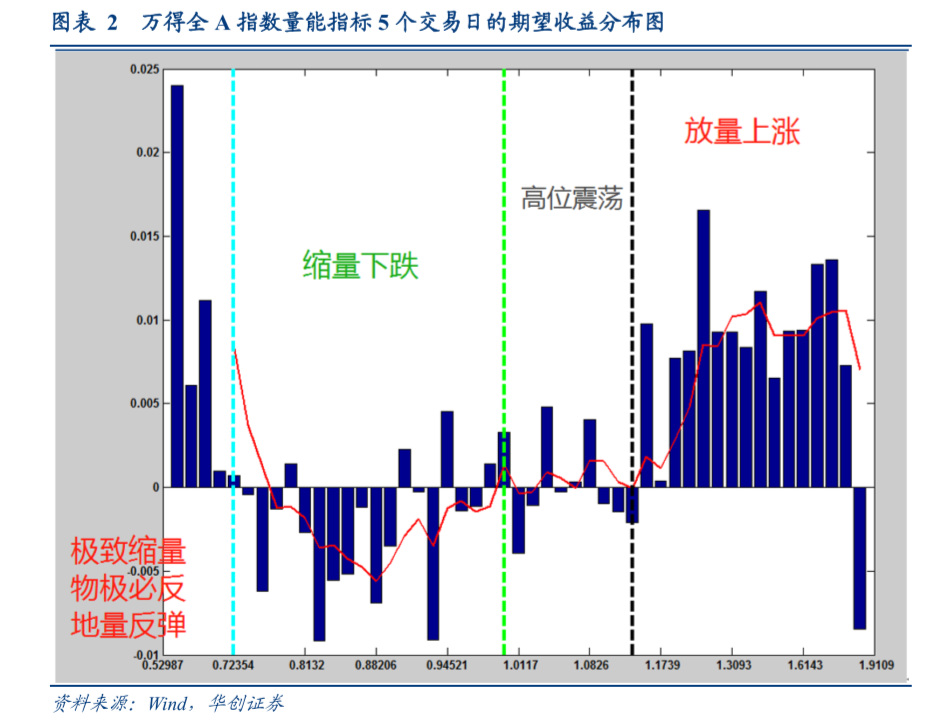

下面我们复现的特征分布情况,这里用的L=45

GridSpec(1, 5)

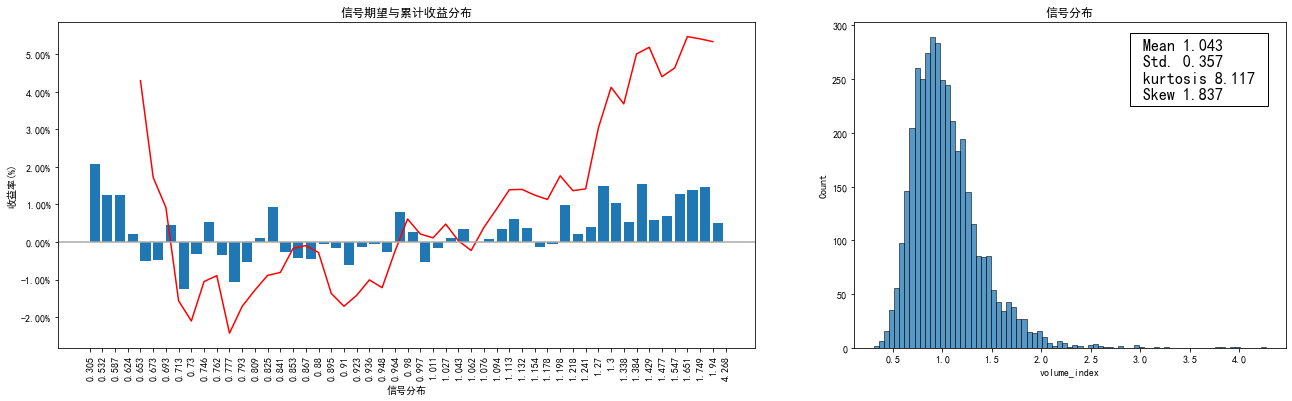

In [3]:
# 测试区间
start_dt, end_dt = "2004-01-01", "2019-12-31"
a = 3.4
df = create_signal(
    data.query('code=="881001.WI"'),
    fast_window=5,
    slow_window=100,
    start_dt=start_dt,
    end_dt=end_dt,
    threshold=1.15,
    a=a,
)

plot_distribution(df["volume_index"], df["forward_returns"], 5, 50, False)

## 信号与标的一览

2004年至2019年信号与指数的情况

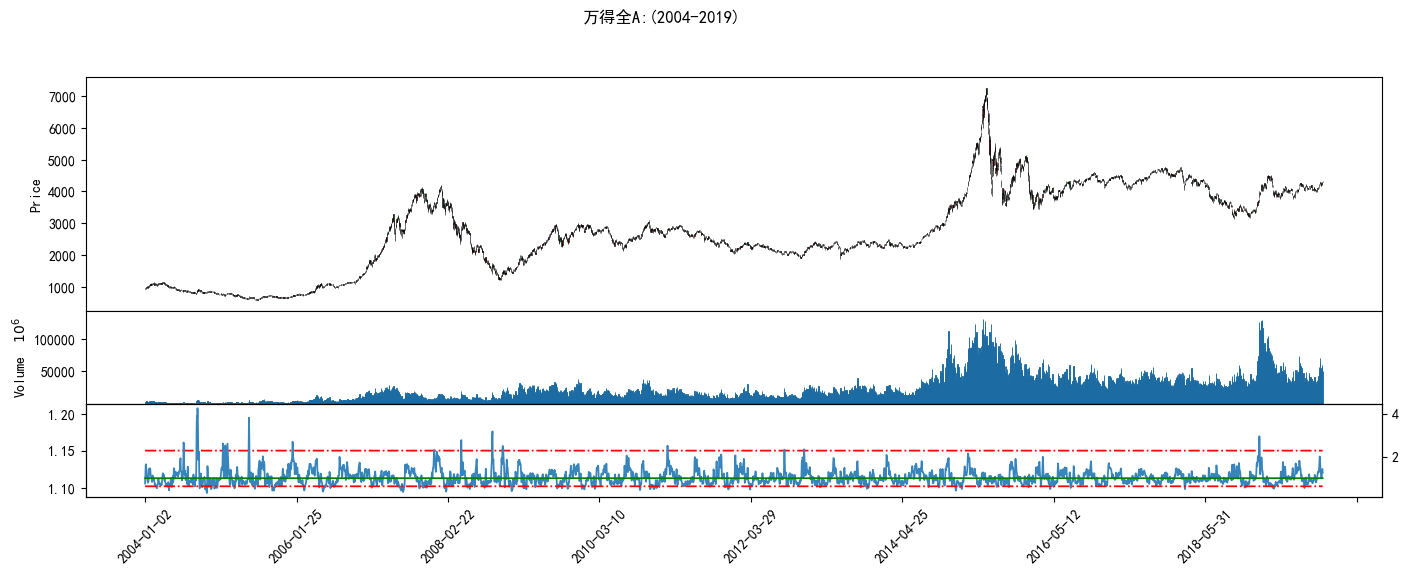

In [4]:
plot_indicator(df, "万得全A:(2004-2019)")


查看细节部分

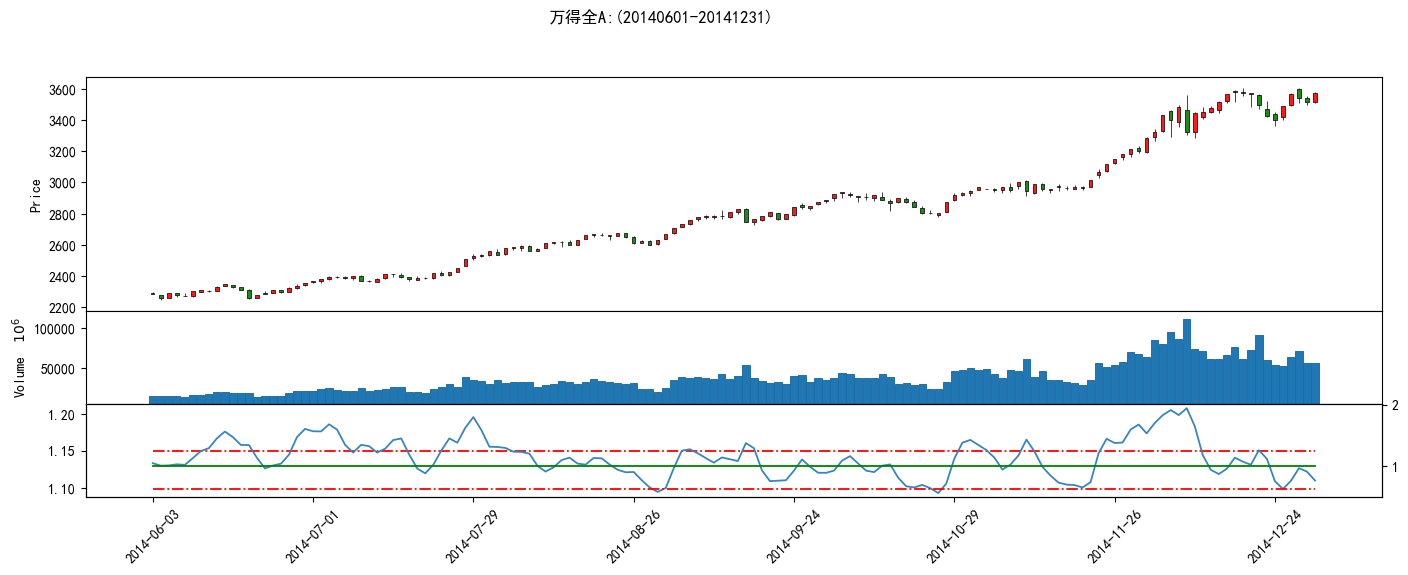

In [7]:
plot_indicator(df.loc["2014-06-01":"2014-12-31"], "万得全A:(20140601-20141231)")


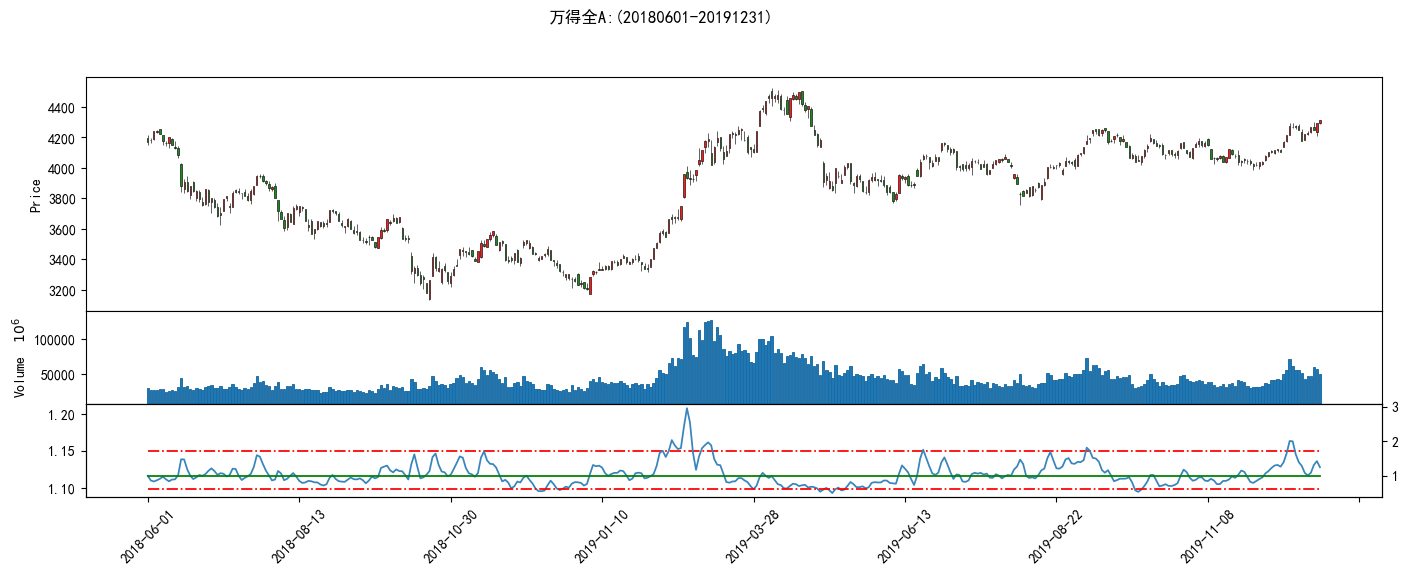

In [8]:
plot_indicator(df.loc["2018-06-01":"2019-12-31"], "万得全A:(20180601-20191231)")


# 回测

交易规则:

- 量能指标大于阈值Threshold=1.15,就做多全A指数;
- 当量能指标小于1且大于$threshold^{-a}$ (其中$a\in$[1.5,3.5])阈值,那么做空全A指数;
- 当量能指标小于$threshold^{-a}$，市场处于地量反弹的区域，后市做多

In [4]:
# 高斯过程的贝叶斯优化
def opt_strategy(data: pd.DataFrame, name: str,random_state:int=None, **kw):
    """用于参数优化"""

    def _runstrats(x, data, name, strategy):
        """目标函数为年化收益率"""
        a, fast_window, slow_window = x
        if fast_window >= slow_window:
            return 0
        res = get_backtesting(
            data,
            name,
            strategy,
            a=a,
            fast_window=fast_window,
            slow_window=slow_window,
            print_log=False,
            **kw
        )

        return -res[0][0].analyzers._Returns.get_analysis()["rnorm100"]

    res = gp_minimize(
        lambda x: _runstrats(x, data, name, bimodal_distribution_strategy),
        [(1.5, 3.5), (5, 180), (5, 300)],
        x0=[1.5, 5, 10],  # 初始参数
        n_calls=100,
        acq_func='EI',
        random_state=random_state,
    )

    return res

In [5]:
# 样本内使用opt寻找最优参数
start_dt, end_dt = "2004-01-01", "2019-12-31"
sel_cols: list = "close,open,high,low,volume".split(",")

df: pd.DataFrame = data.query('code=="881001.WI"').loc[start_dt:end_dt, sel_cols]

df: pd.DataFrame = df.dropna()

opt_param = opt_strategy(df, "wind_A")

In [6]:
# 回测
bt_params: Dict = dict(zip(["a", "fast_window", "slow_window"], opt_param.x))
print(f"最优参数:{bt_params}")

# 当参数trade_long为False时开启多空 为True时仅多头
bt_result = get_backtesting(
    df,
    "wind_A",
    bimodal_distribution_strategy,
    **bt_params,
    trade_long=False,
    print_log=False,
)

最优参数:{'a': 3.5, 'fast_window': 5, 'slow_window': 78}


## 回测结果一览

In [7]:
analysis_rets(df["close"], bt_result.result)

    'data': [{'cells': {'align': [left, center],
                        'font':…

In [8]:
analysis_trade(df["close"], bt_result.result)


    'data': [{'cells': {'align': [left, center],
                        'font':…

## 极端参数遍历的万得全A指数缩量下跌和地量反弹回测结果

In [14]:
start_dt, end_dt = "2004-01-01", "2019-12-31"
sel_cols: list = "close,open,high,low,volume".split(",")
df = data.query('code=="881001.WI"').loc[start_dt:end_dt, sel_cols].dropna()
results = get_backtesting(
    df,
    "wind_A",
    bimodal_distribution_strategy,
    is_opt=True,
    a=np.arange(1.5, 3.6, 0.1),
    fast_window=5,
    slow_window=100,
)

In [15]:
# 获取参数列表
par_df: pd.DataFrame = get_opt_stratgey_table(results.result)


<Figure size 1400x700 with 0 Axes>

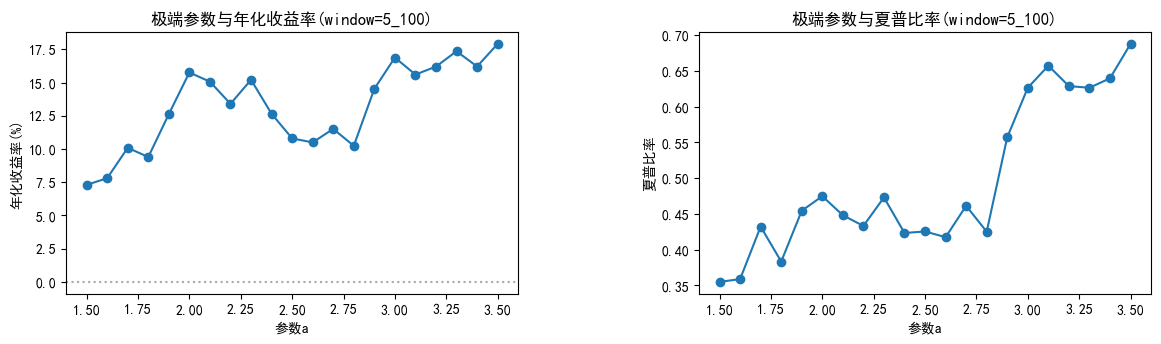

In [16]:
plot_params_table_visualization(par_df, rows=len(par_df.index.levels[0]))

In [17]:
# 展示最优参数的列表情况
(
    par_df.loc["5_100"]
    .style.format("{:.2f}")
    .highlight_max(color="#ffe6e6", axis=0)
    .highlight_min(color="#e6ffe6", axis=0)
)

,年化收益率(%),最大回撤(%),夏普,交易总数,胜率(%),盈亏比,多头胜率(%),多头盈亏比,空头胜率(%),空头盈亏比
参数a,,,,,,,,,,
1.500000,7.30,-57.23,0.35,671.00,47.24,1.06,51.34,1.48,44.09,0.81
1.600000,7.80,-56.32,0.36,669.00,47.83,1.06,51.84,1.47,44.72,0.82
1.700000,10.09,-52.19,0.43,662.00,47.89,1.10,52.01,1.48,44.63,0.88
1.800000,9.39,-56.24,0.38,660.00,47.12,1.09,51.70,1.44,43.56,0.89
1.900000,12.62,-56.27,0.45,656.00,48.63,1.11,53.26,1.47,45.05,0.92
2.000000,15.76,-51.10,0.47,639.00,48.83,1.15,54.26,1.54,44.66,0.95
2.100000,15.06,-51.37,0.45,621.00,48.79,1.14,54.07,1.53,44.86,0.96
2.200000,13.39,-50.72,0.43,618.00,47.73,1.13,52.99,1.54,43.84,0.94
2.300000,15.21,-48.80,0.47,603.00,47.76,1.16,54.41,1.62,42.82,0.95


与研报不同,研报中
>随着极端参数从1.5遍历至3.5，缩量下跌与地量反弹的万得全A择时年化收益和夏普比率随着参数值的增加而递增，在极端参数为2.3年化与夏普达到最高，然后极端参数从2.3至3.5年化和夏普比率又逐渐降低，最终在极端参数为 3.5的时候年化与夏普最低，印证了极端参数需要大于 2，但是又不能过高

而在这里是单调递减的,研报中并没说明核心参数L的长度,后续可以试着遍历参数找出适合的L

可视化参数列表,累计收益最高的参数为window=20,a=3.4

## 样本外测试

可以看到样本外拉跨....

In [18]:
# 回测
begin_dt, end_dt = "2020-01-01", "2022-07-31"
sel_cols: list = "close,open,high,low,volume".split(",")

df = data.query('code=="881001.WI"').loc[begin_dt:end_dt, sel_cols]
# 当参数trade_long为False时开启多空 为True时仅多头
# bt_params = {'a': 3.48480696642093, 'fast_window': 5, 'slow_window': 80}
bt_result = get_backtesting(
    df,
    "wind_A",
    bimodal_distribution_strategy,
    **bt_params,
    trade_long=False,
    print_log=False
)

In [19]:
analysis_rets(df["close"], bt_result.result)


    'data': [{'cells': {'align': [left, center],
                        'font':…

In [20]:
analysis_trade(df["close"], bt_result.result)


    'data': [{'cells': {'align': [left, center],
                        'font':…

## 宽基指数测试

In [21]:
# 批量获取回测信息
def bulk_backtrader(
    data: pd.DataFrame, params: Dict, start_dt: str = None, end_dt: str = None
) -> Dict:

    sel_cols: list = "close,open,high,low,volume".split(",")

    res_dic: Dict = {}

    for name, df in data.groupby("code"):

        kwargs = params[name]

        if (start_dt is not None) and (end_dt is not None):

            df = df.loc[start_dt:end_dt, sel_cols].dropna()

        else:

            df = df[sel_cols].dropna()

        try:
            res_dic[name] = get_backtesting(
                df, name, bimodal_distribution_strategy,print_log=False, **kwargs
            ).result
        except Exception as e:

            print(f"回测{name}时出错")
            raise e

    return res_dic

宽基指数信号及收益分布情况

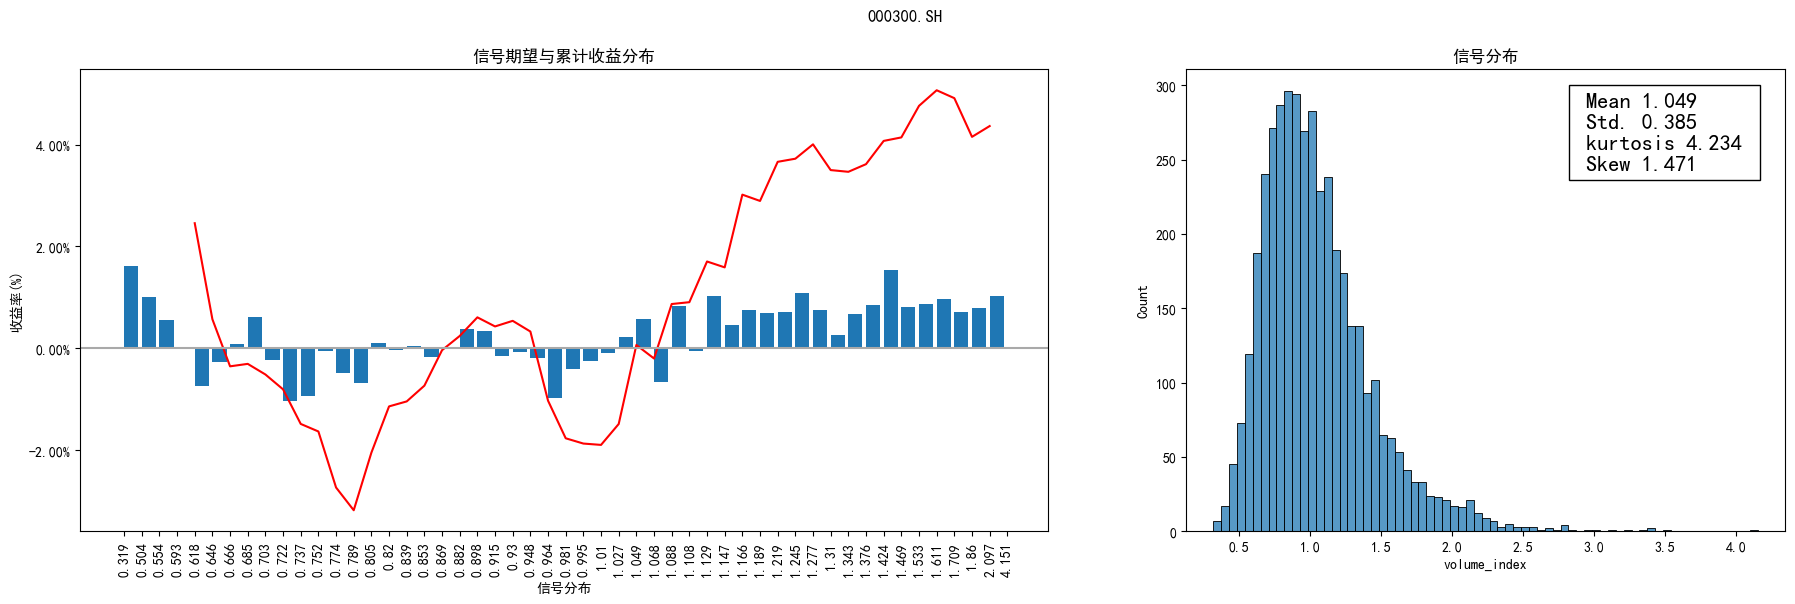

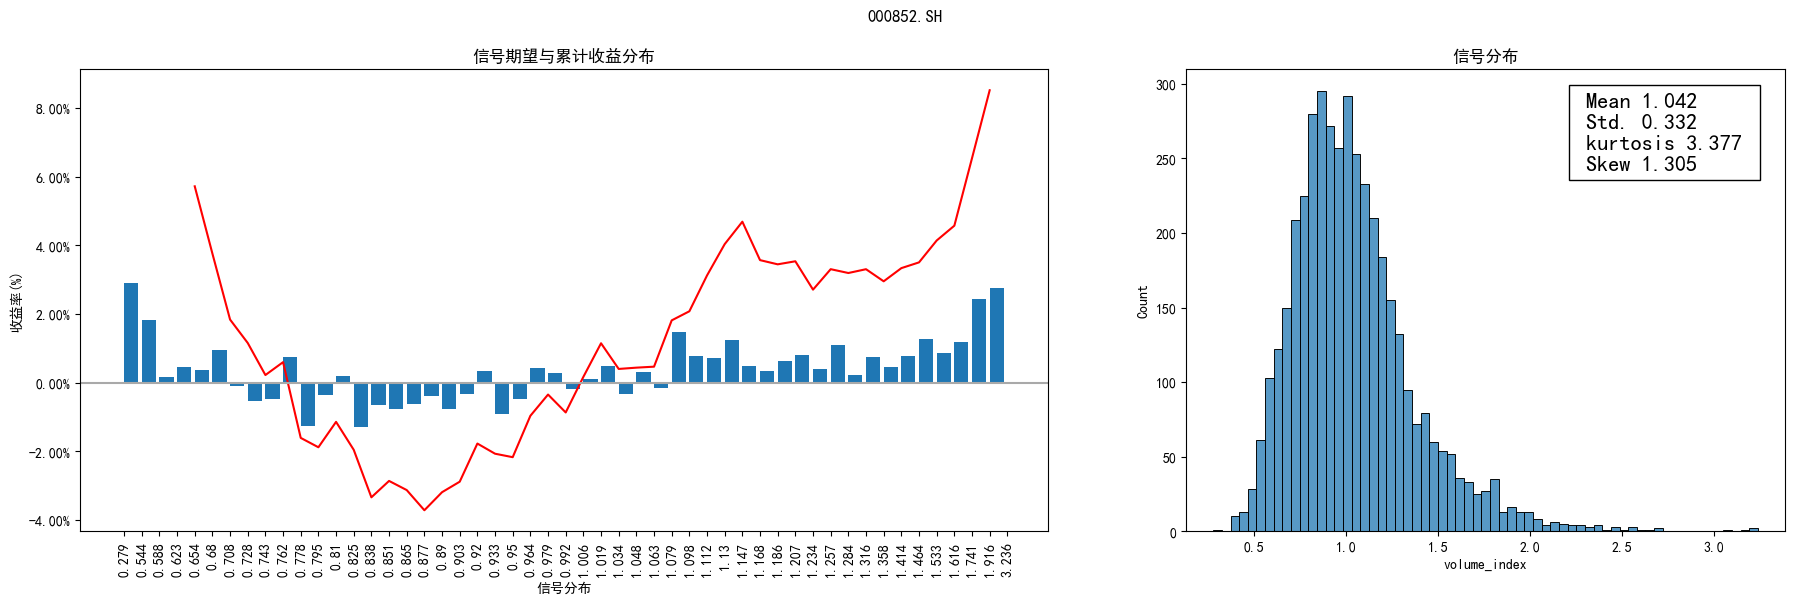

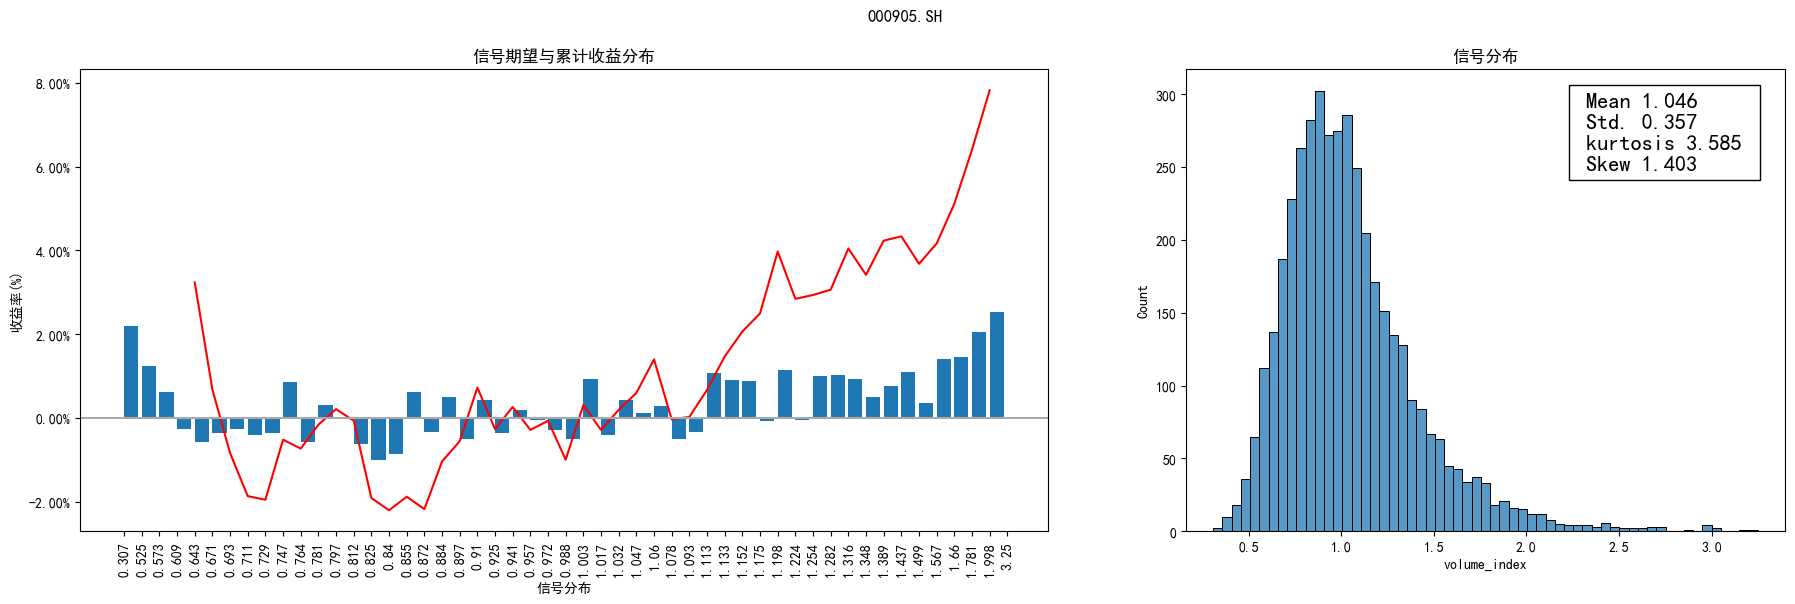

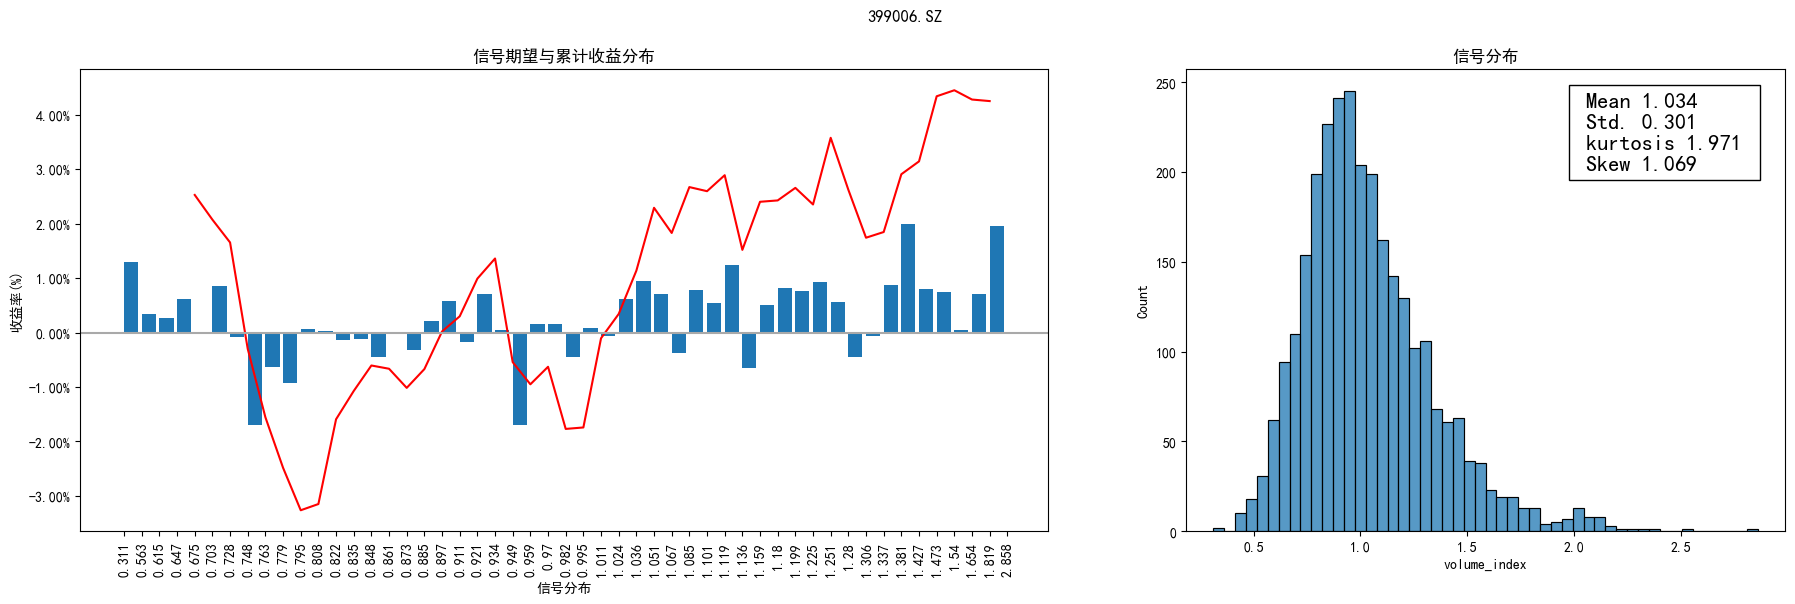

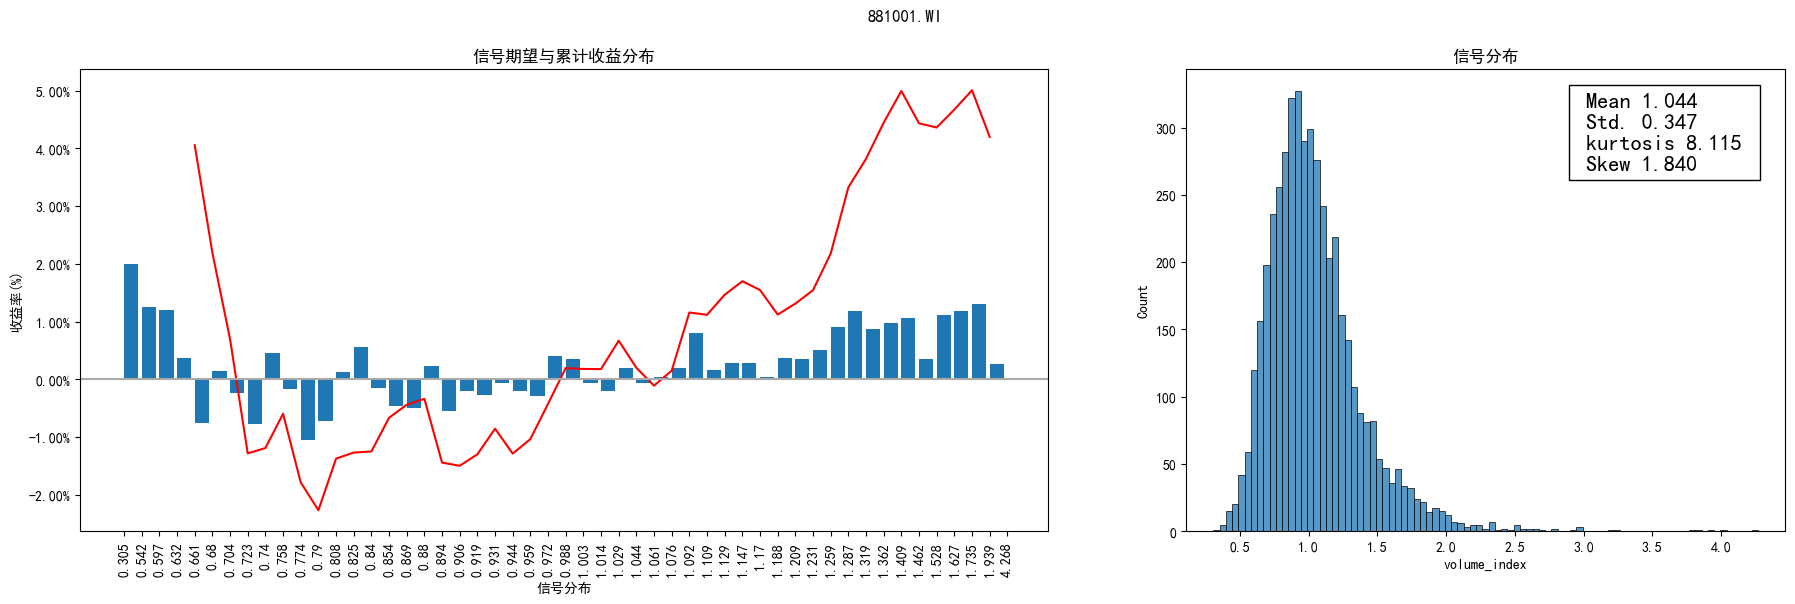

In [22]:
for name, df in data.groupby("code"):

    df = create_signal(
        data.query(f'code=="{name}"'),
        fast_window=5,
        slow_window=100,
        threshold=1.15,
        a=1.5,
    )

    plot_distribution(
        df["volume_index"], df["forward_returns"], 5, 50, False, title=name
    )

使用opt函数对每个指数进行寻参,并进行回测

In [43]:
# 回测
start_dt, end_dt = "2004-01-01", "2019-12-31"

sel_cols: List = "close,open,high,low,volume".split(",")

bulk_params: Dict = {
    name: dict(
        zip(
            ["a", "fast_window", "slow_window"],
            opt_strategy(df.loc[start_dt:end_dt, sel_cols].dropna(), name).x,
        )
    )
    for name, df in data.groupby("code")
}

print(f"寻参结果如下:{bulk_params}")

bt_result: Dict = bulk_backtrader(data, bulk_params, start_dt, end_dt)

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimize

寻参结果如下:{'000300.SH': {'a': 1.5, 'fast_window': 146, 'slow_window': 290}, '000852.SH': {'a': 1.5, 'fast_window': 102, 'slow_window': 300}, '000905.SH': {'a': 3.5, 'fast_window': 21, 'slow_window': 117}, '399006.SZ': {'a': 3.5, 'fast_window': 19, 'slow_window': 197}, '881001.WI': {'a': 3.5, 'fast_window': 5, 'slow_window': 78}}


根据拟合的参数进行回测,结果如下

<Figure size 1400x2100 with 0 Axes>

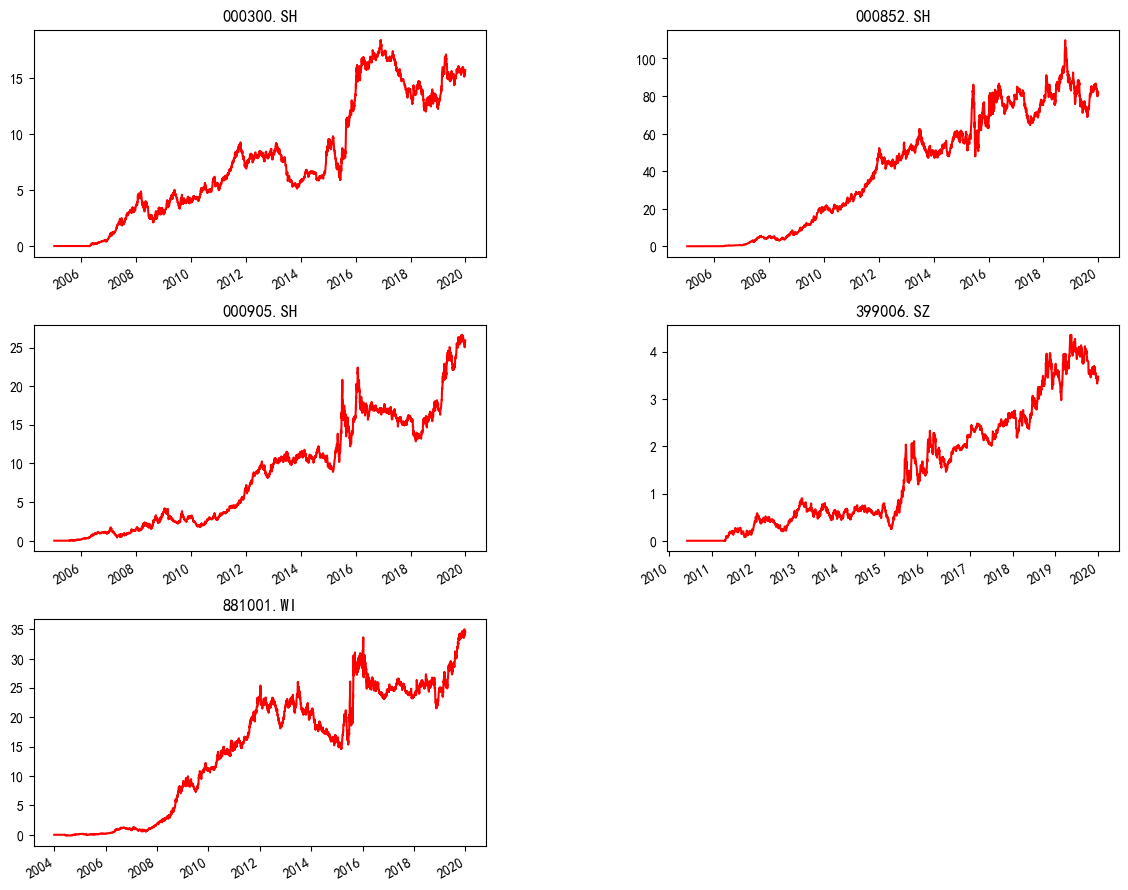

In [44]:
size = len(bt_result)
cols = 2
rows = size // 2 + 1 if size % 2 else size * 0.5
g = GridFigure(rows, cols)
g.fig = plt.figure(figsize=(14, rows * 4))

for k, result in bt_result.items():

    cum = ep.cum_returns(get_time_returns(result[0]))
    cum.plot(title=k, color="r", ax=g.next_cell())

plt.show()
g.close()

## 行业情况

遍历31个申万一级行业的“最优”参数

In [45]:
# 读取数据
sw_level: pd.DataFrame = pd.read_csv(
    "data/sw_level1.csv",
    index_col=["trade_date"],
    parse_dates=["trade_date"],
    encoding="gbk",
)

sw_level = sw_level.rename(columns={"code": "sec_name", "sec_name": "code"})
# 过滤退市的行业
sw_level = sw_level[~sw_level["code"].str.contains("退市")]

sw_level.sort_index(inplace=True)
# 获取数据大于300的行业
cond = (sw_level.groupby('code')['sec_name'].count() >= 300)
sw_level = sw_level[sw_level['code'].isin(cond[cond].index.tolist())]

In [46]:
sel_cols: List = "close,open,high,low,volume".split(",")

bulk_params1: Dict = {
    name: dict(
        zip(
            ["a", "fast_window", "slow_window"],
            opt_strategy(df.loc[start_dt:end_dt, sel_cols].dropna(), name).x,
        )
    )
    for name, df in sw_level.groupby("code")
}

print(f'最优参数为:{bulk_params1}')

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning:

The objective has been evaluated at this point before.

d:\anaconda3\lib\site-packages\skopt\optimizer\optimize

最优参数为:{'交通运输(申万)': {'a': 1.5, 'fast_window': 61, 'slow_window': 289}, '传媒(申万)': {'a': 1.5, 'fast_window': 171, 'slow_window': 300}, '公用事业(申万)': {'a': 2.6506532014217483, 'fast_window': 53, 'slow_window': 172}, '农林牧渔(申万)': {'a': 1.5, 'fast_window': 125, 'slow_window': 244}, '医药生物(申万)': {'a': 2.5752868695214772, 'fast_window': 19, 'slow_window': 300}, '商贸零售(申万)': {'a': 1.502112063399422, 'fast_window': 38, 'slow_window': 256}, '国防军工(申万)': {'a': 1.940586540295536, 'fast_window': 28, 'slow_window': 88}, '基础化工(申万)': {'a': 3.3398025682167862, 'fast_window': 24, 'slow_window': 201}, '家用电器(申万)': {'a': 2.366724340444308, 'fast_window': 77, 'slow_window': 300}, '建筑材料(申万)': {'a': 2.5071674396551336, 'fast_window': 21, 'slow_window': 90}, '建筑装饰(申万)': {'a': 3.5, 'fast_window': 66, 'slow_window': 300}, '房地产(申万)': {'a': 1.5, 'fast_window': 5, 'slow_window': 197}, '有色金属(申万)': {'a': 3.5, 'fast_window': 31, 'slow_window': 120}, '机械设备(申万)': {'a': 2.919826195627615, 'fast_window': 14, 'slow_window': 101},

遍历行业信号分布,可以看到每个行业需要单独研究分析,设置适合的变量参数

d:\WrokSpace\Quantitative-analysis\C-择时类\特征分布建模择时系列之二\scr\plotting.py:348: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).



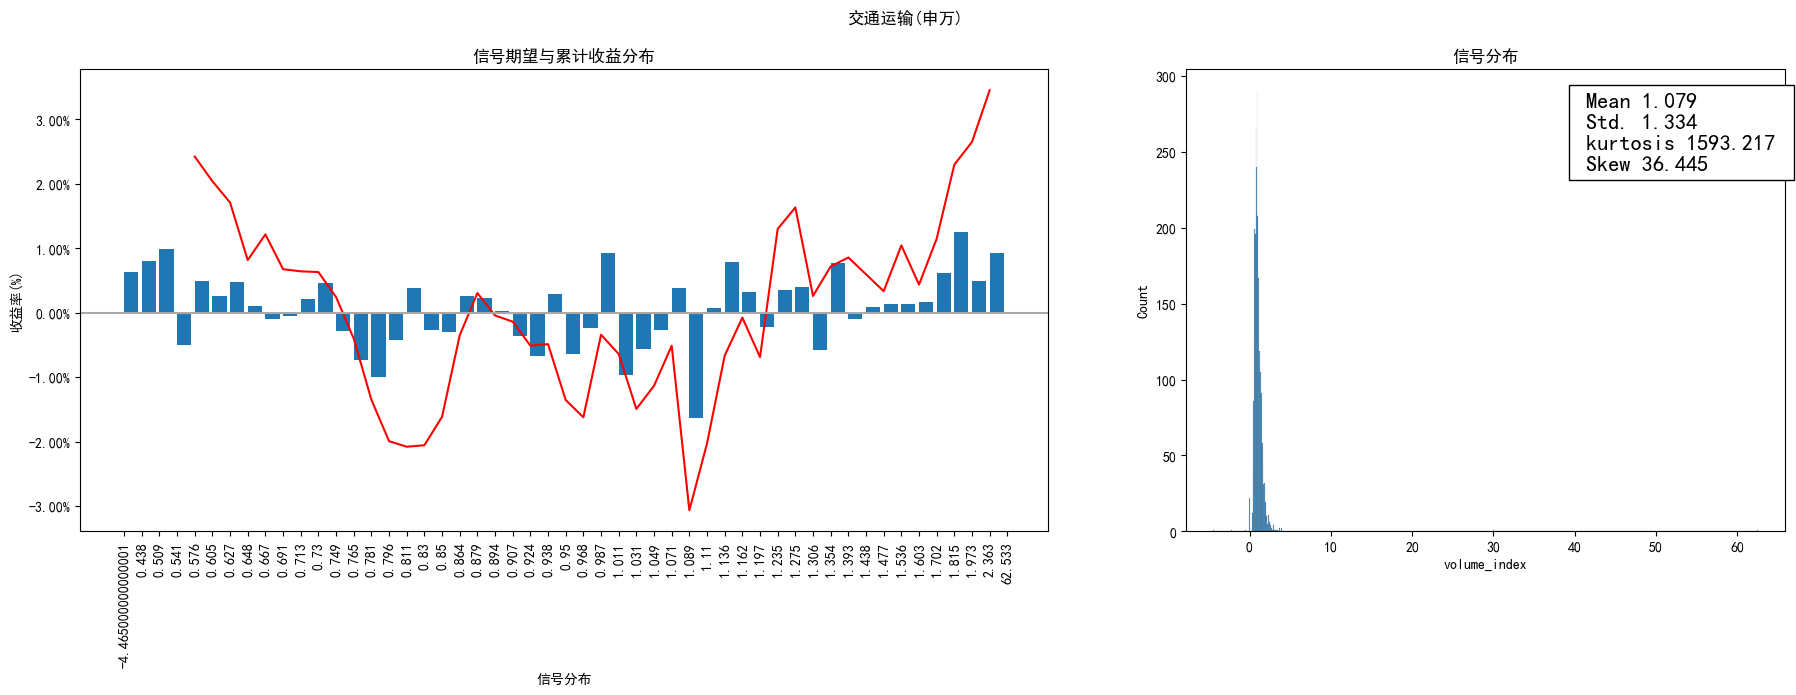

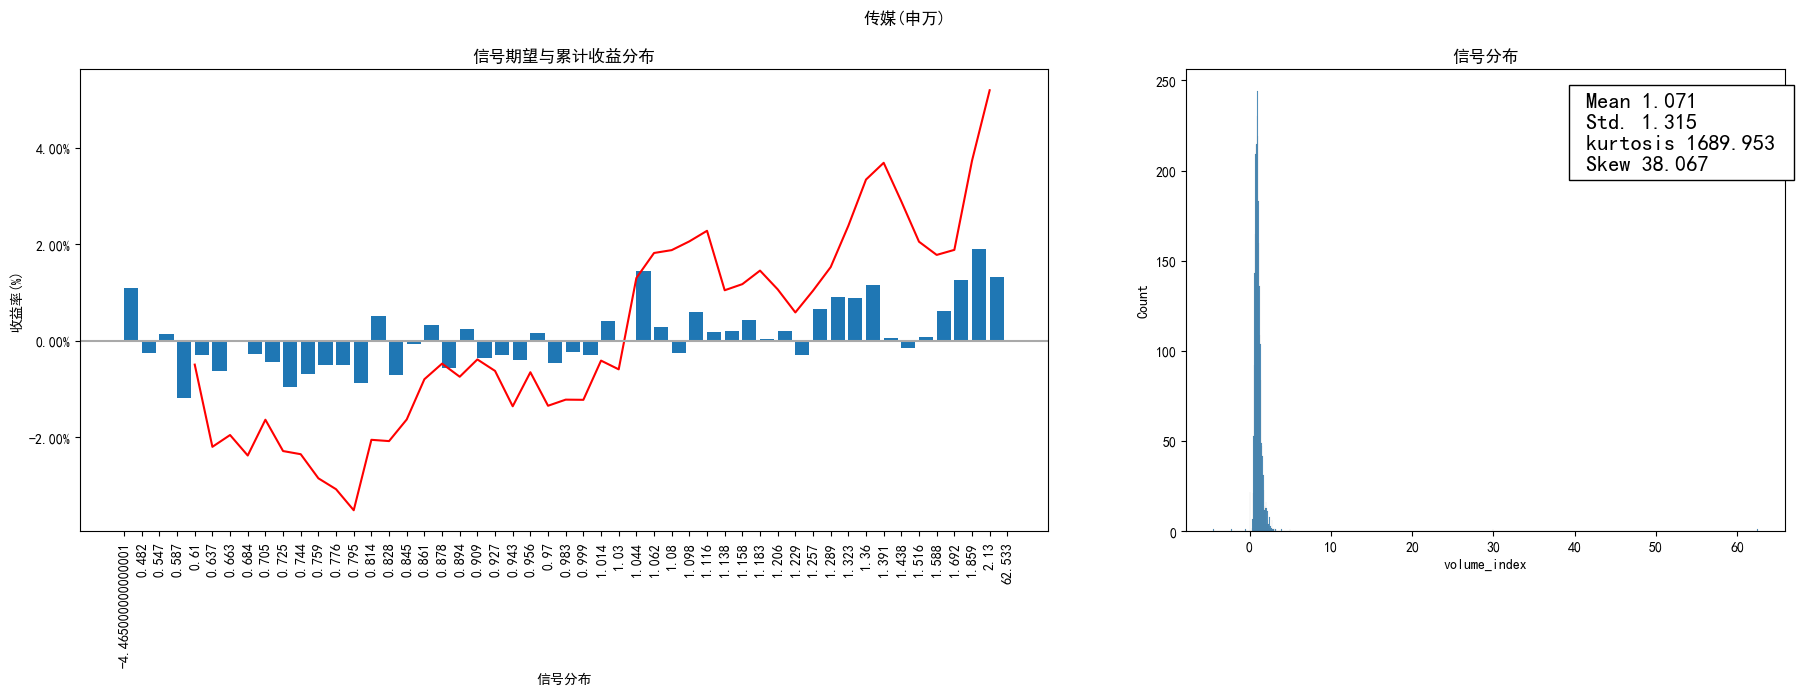

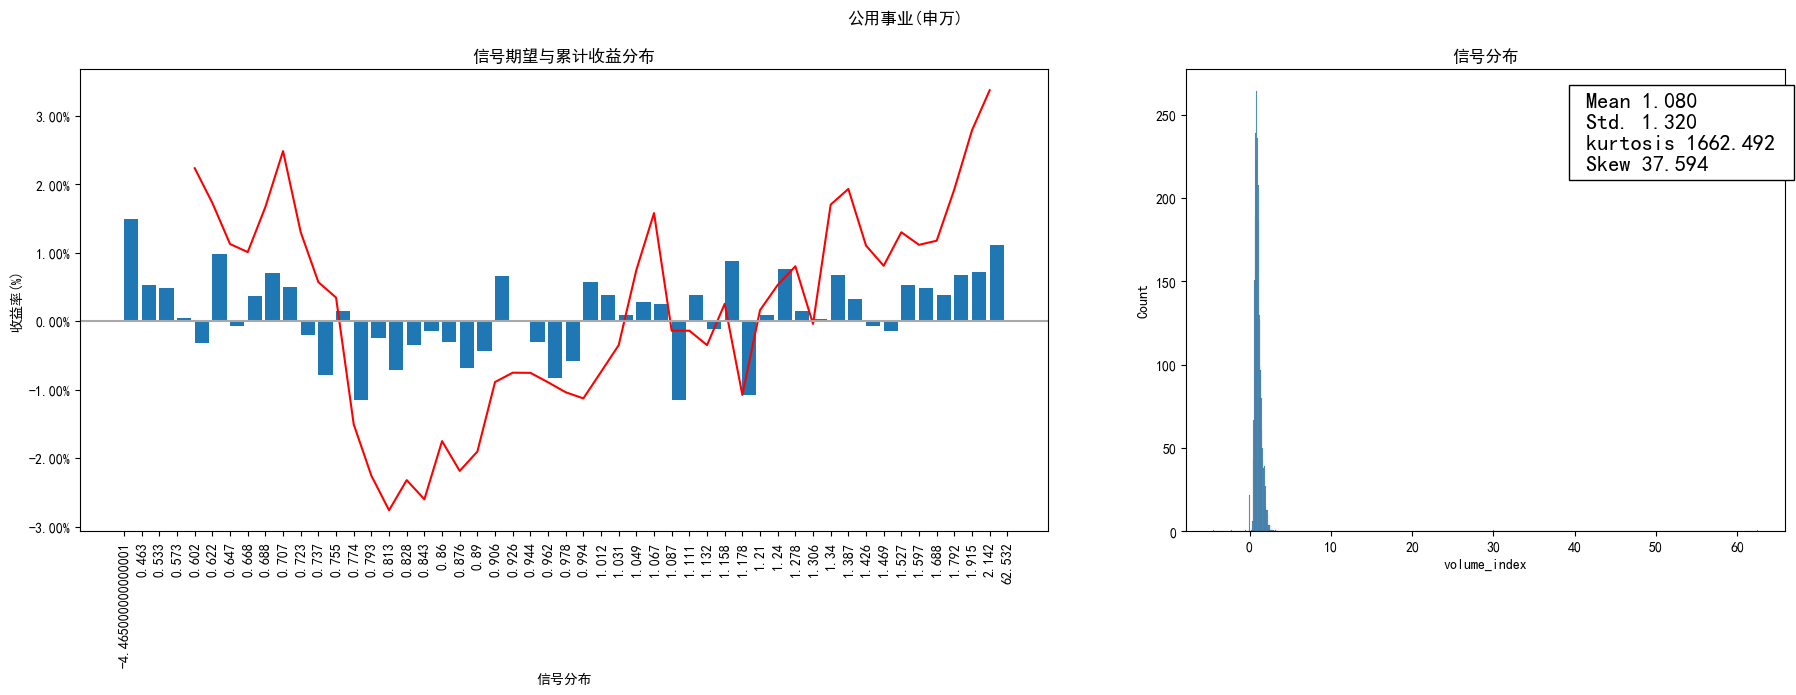

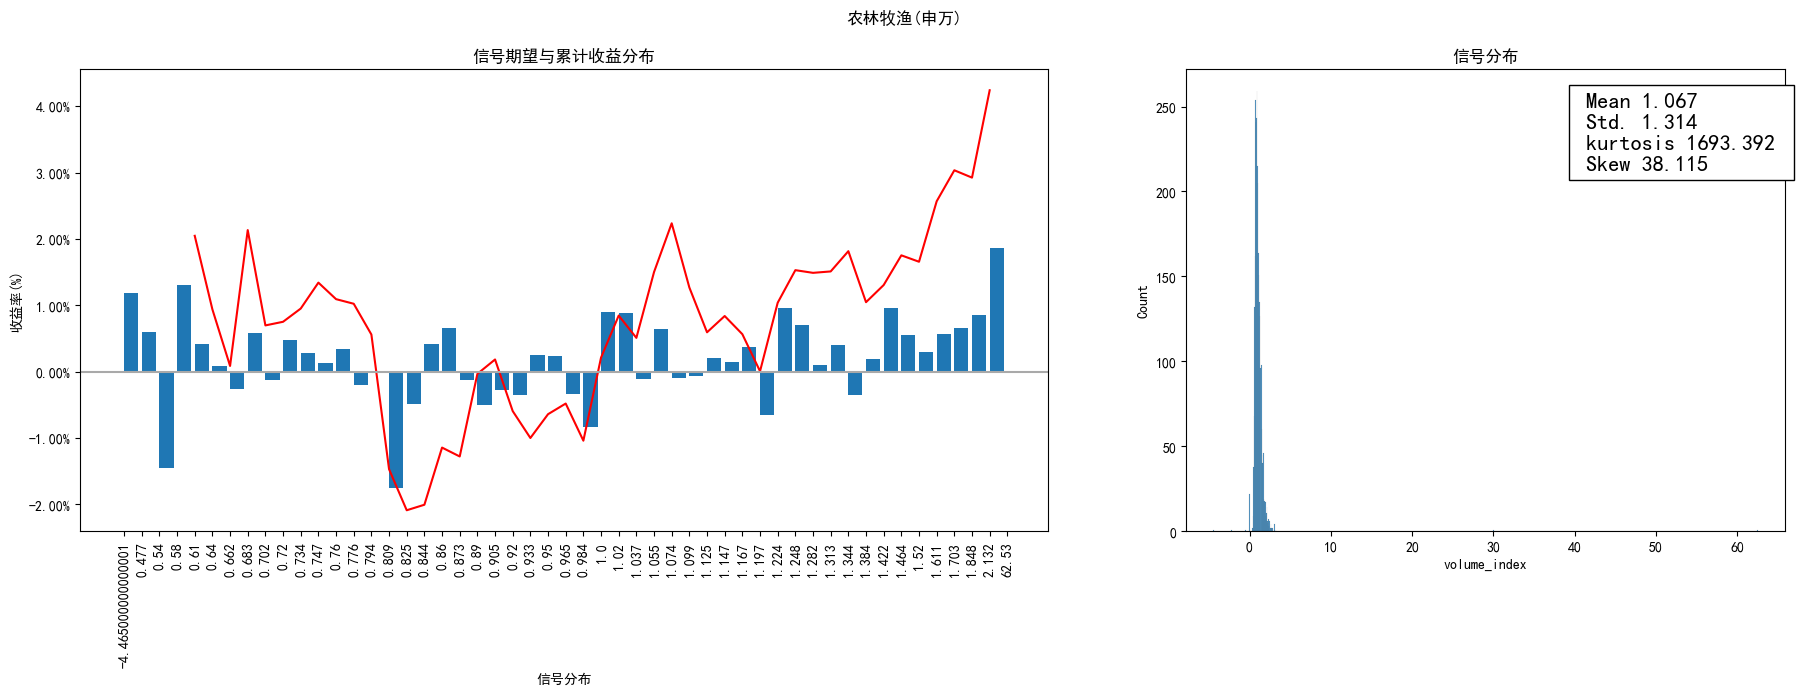

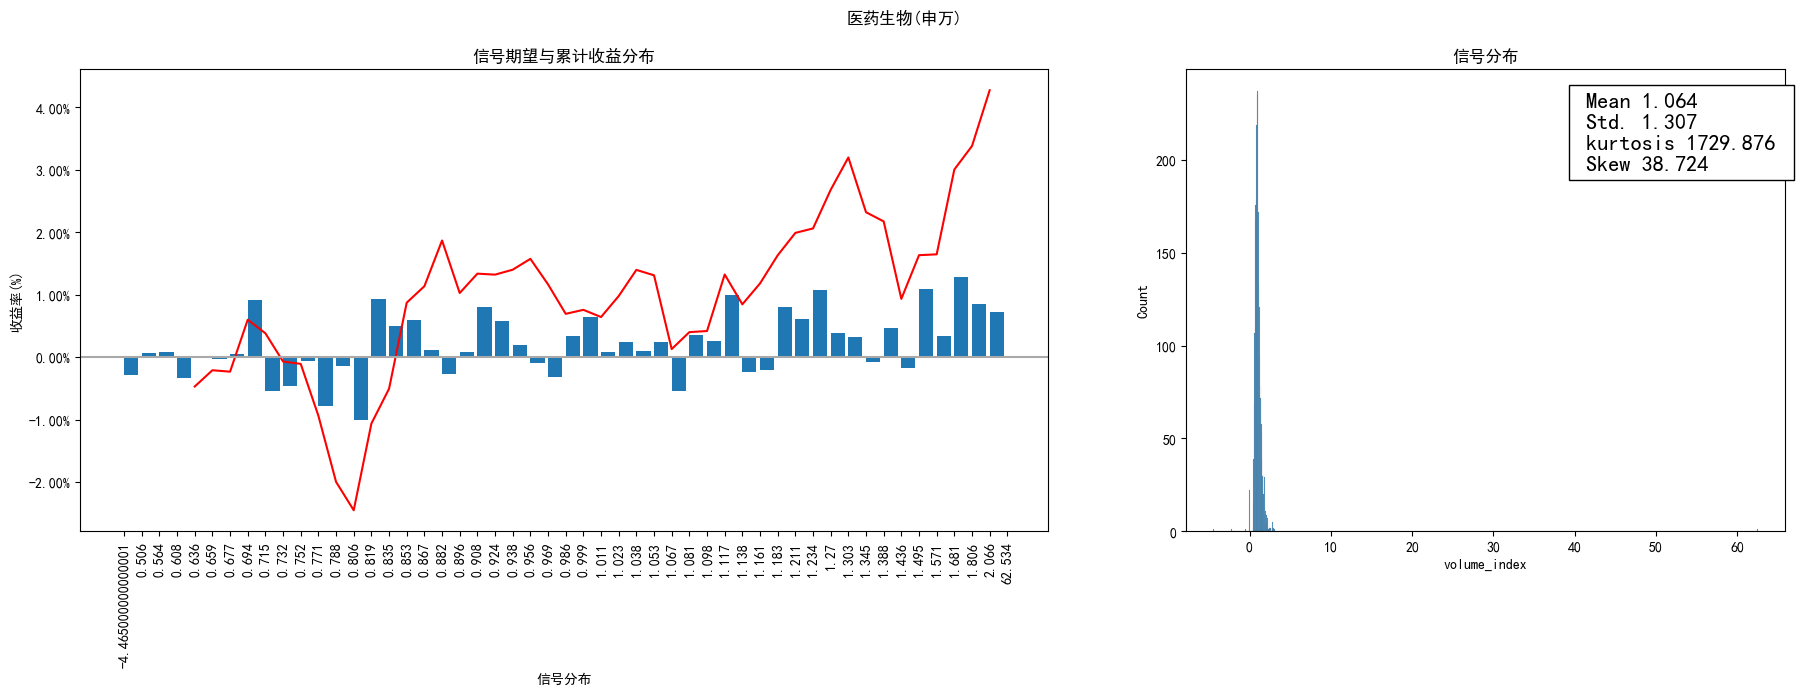

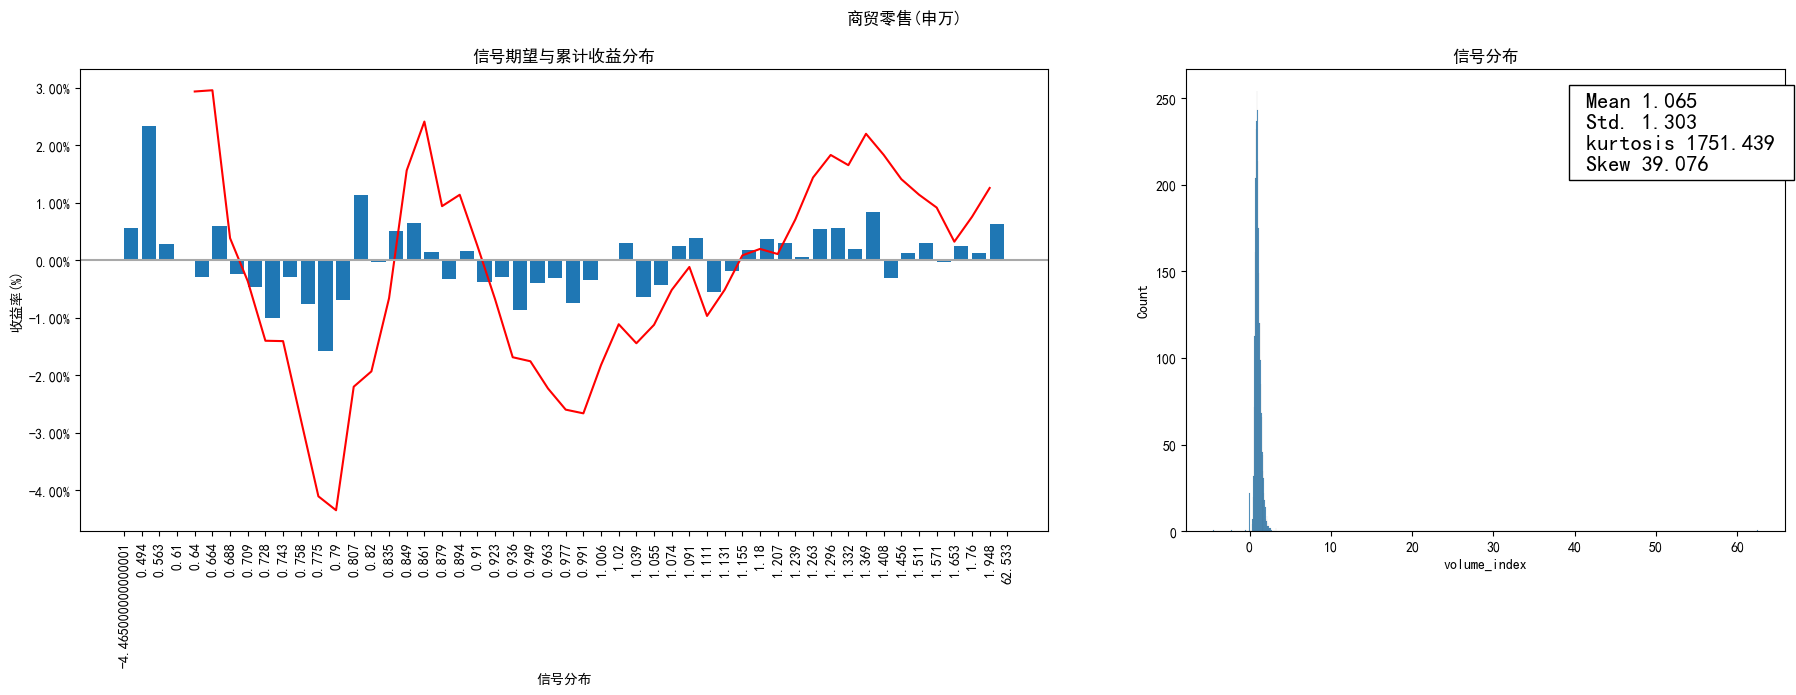

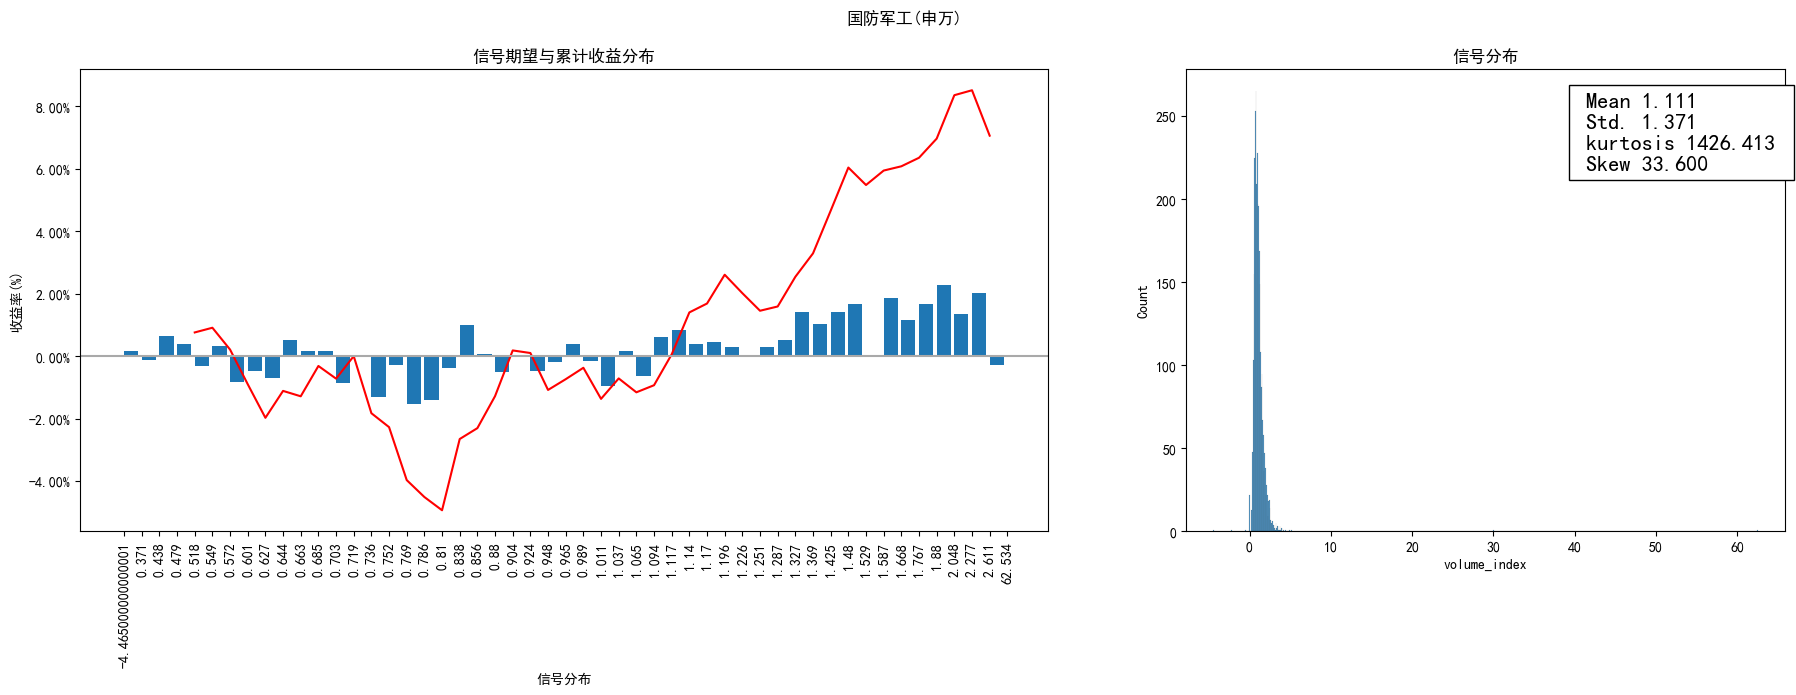

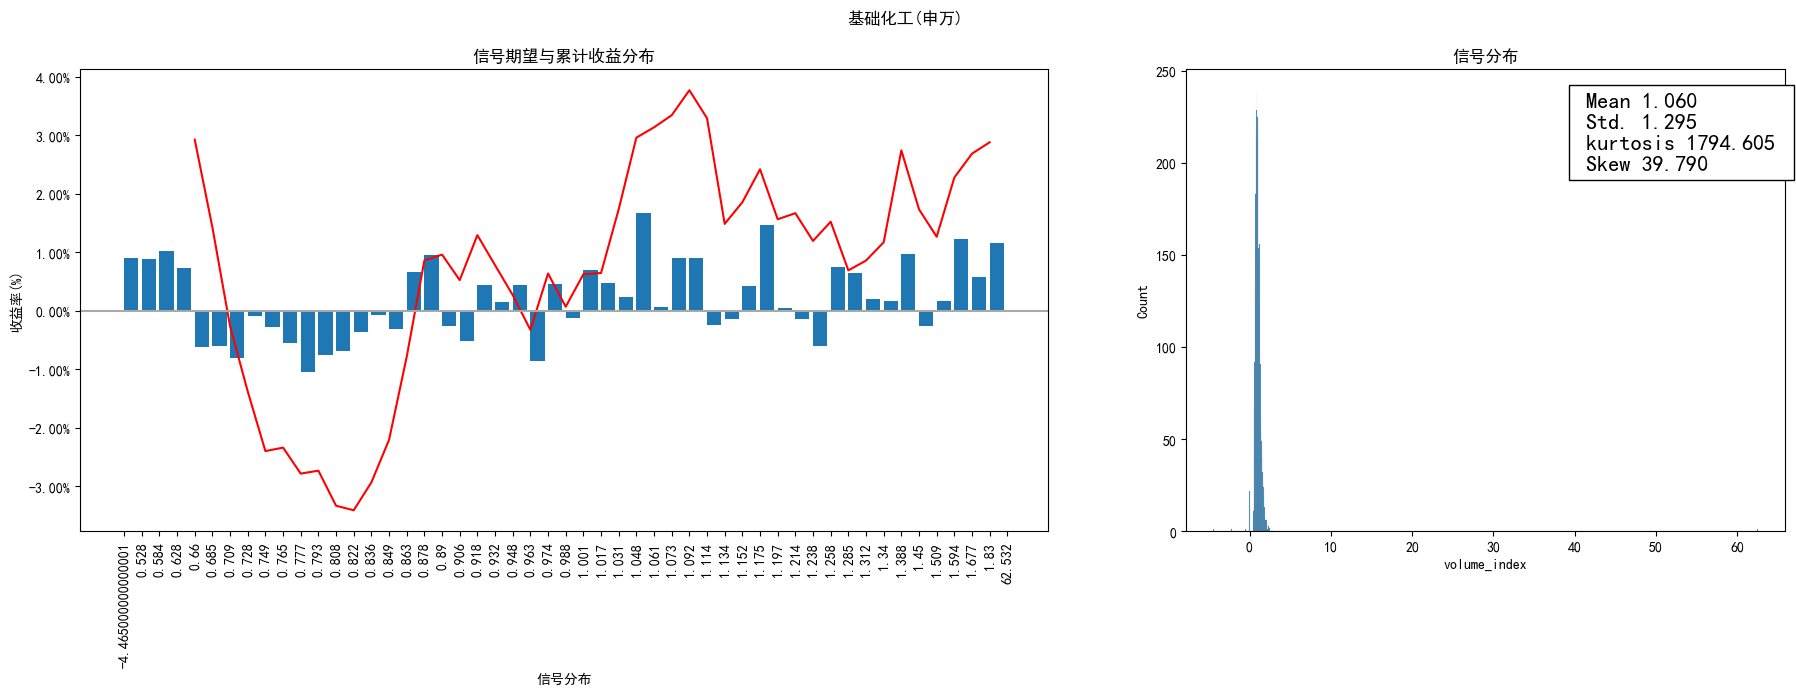

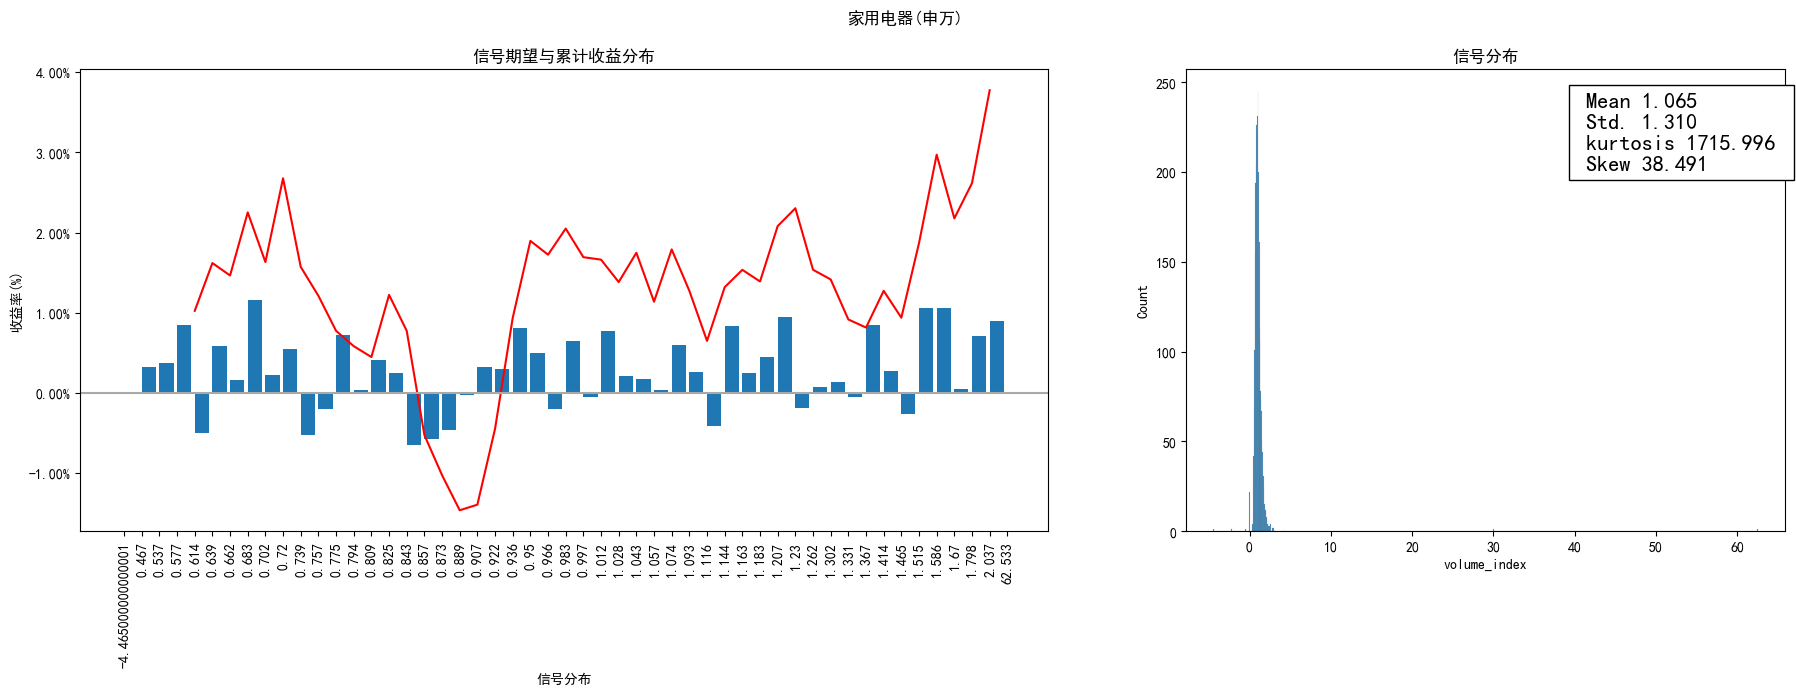

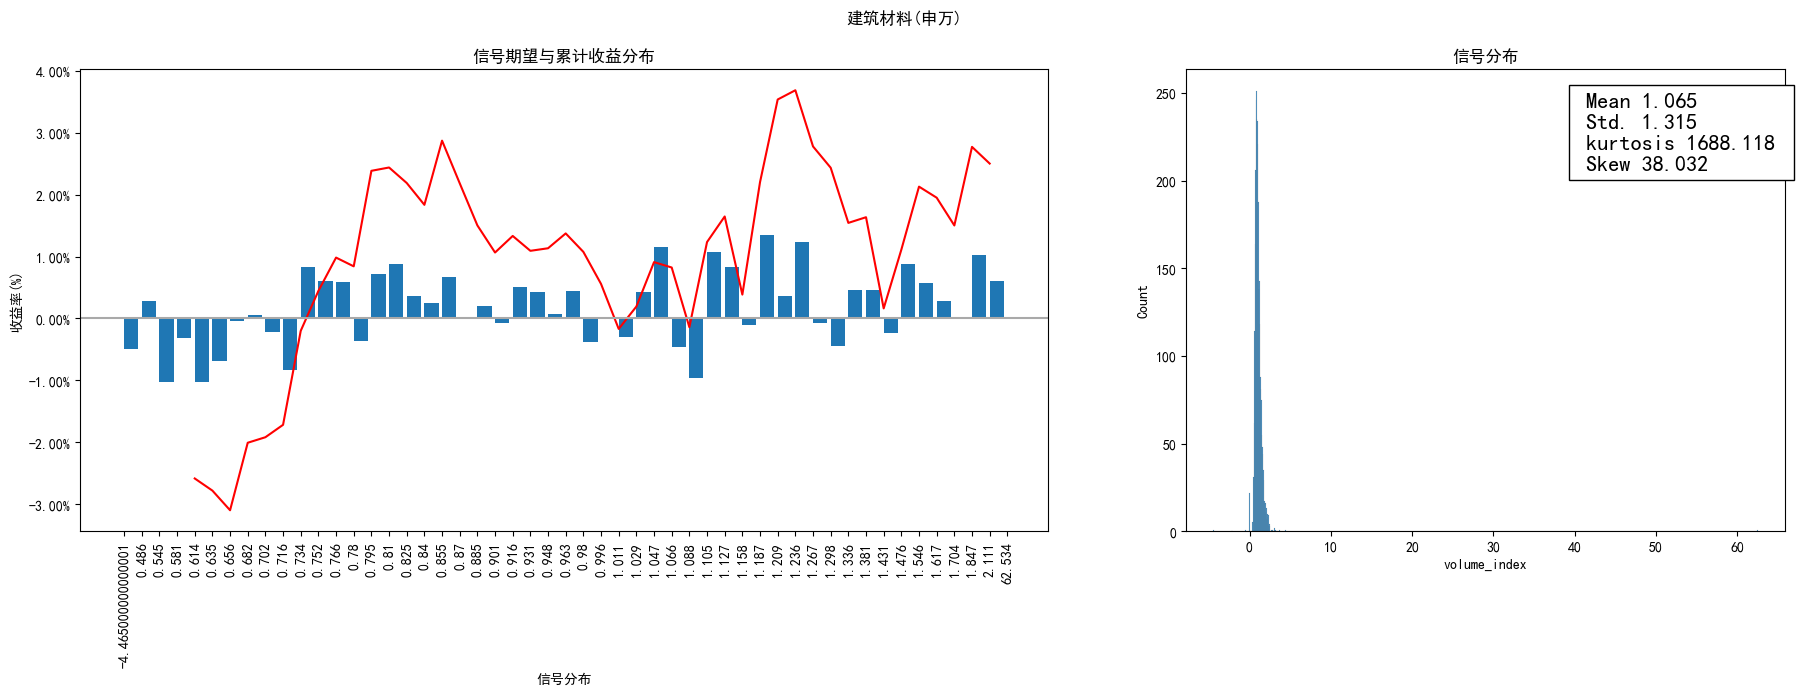

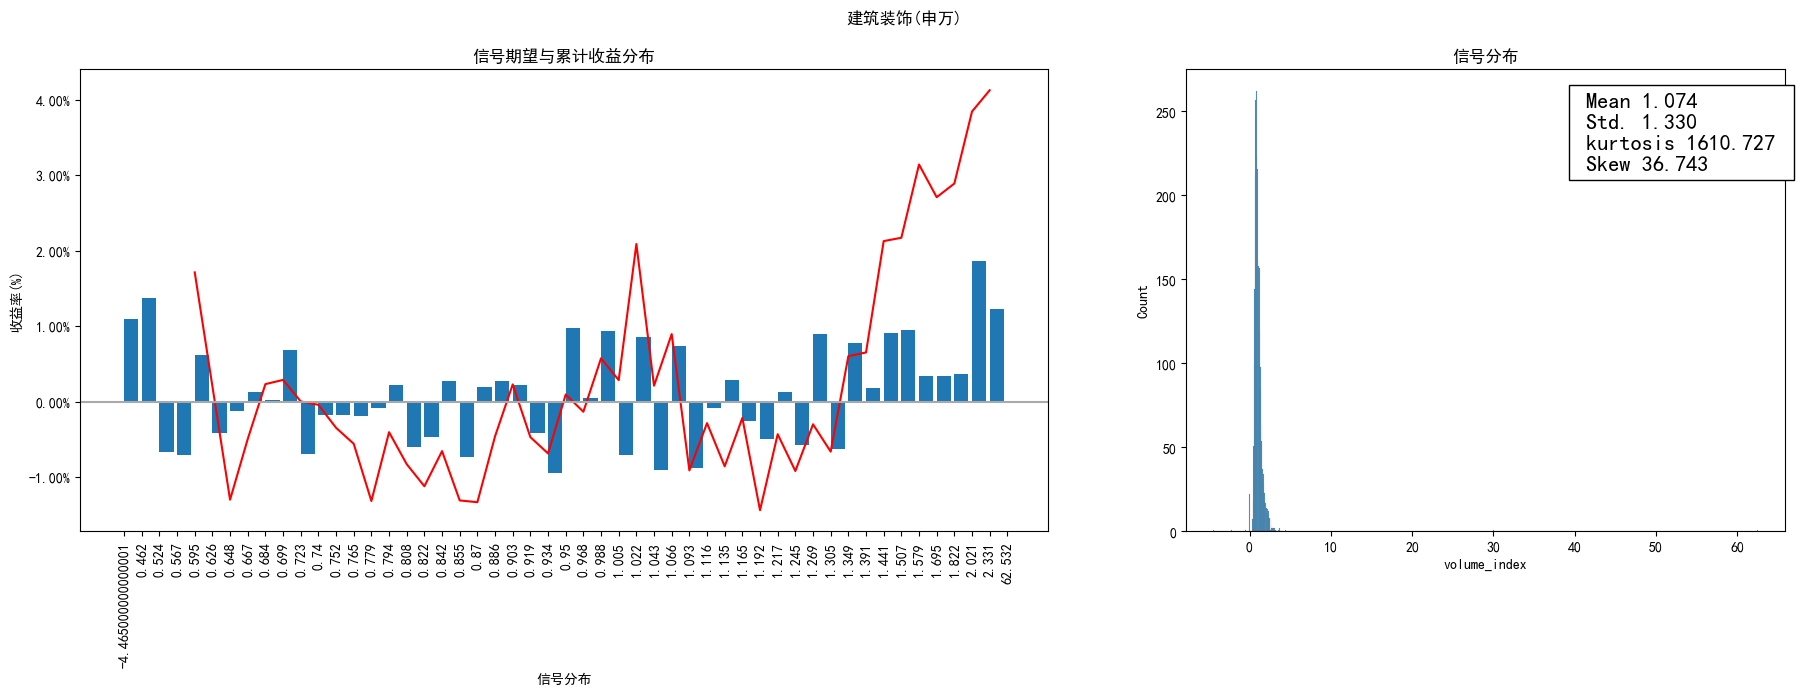

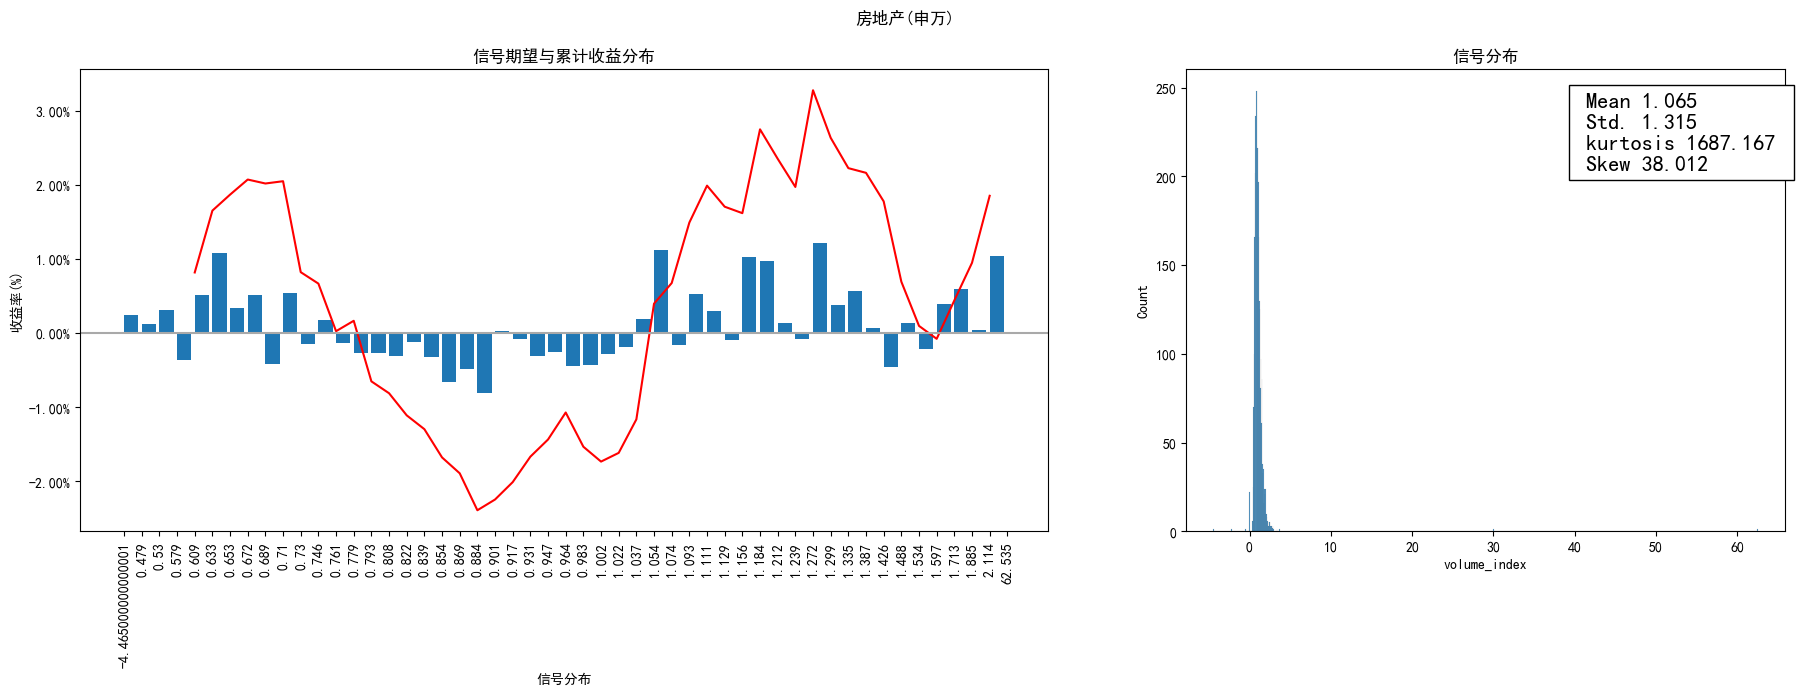

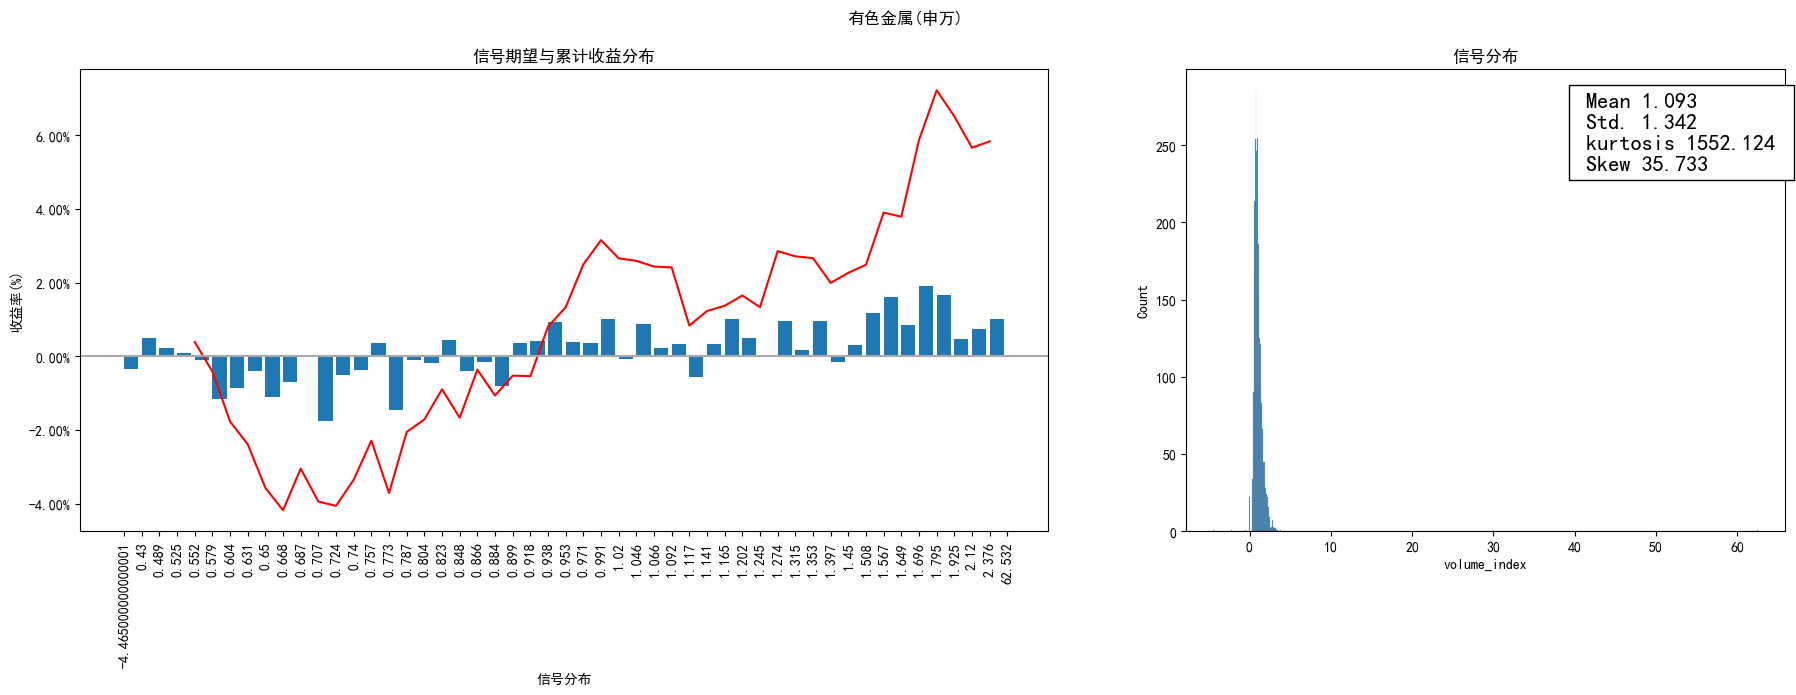

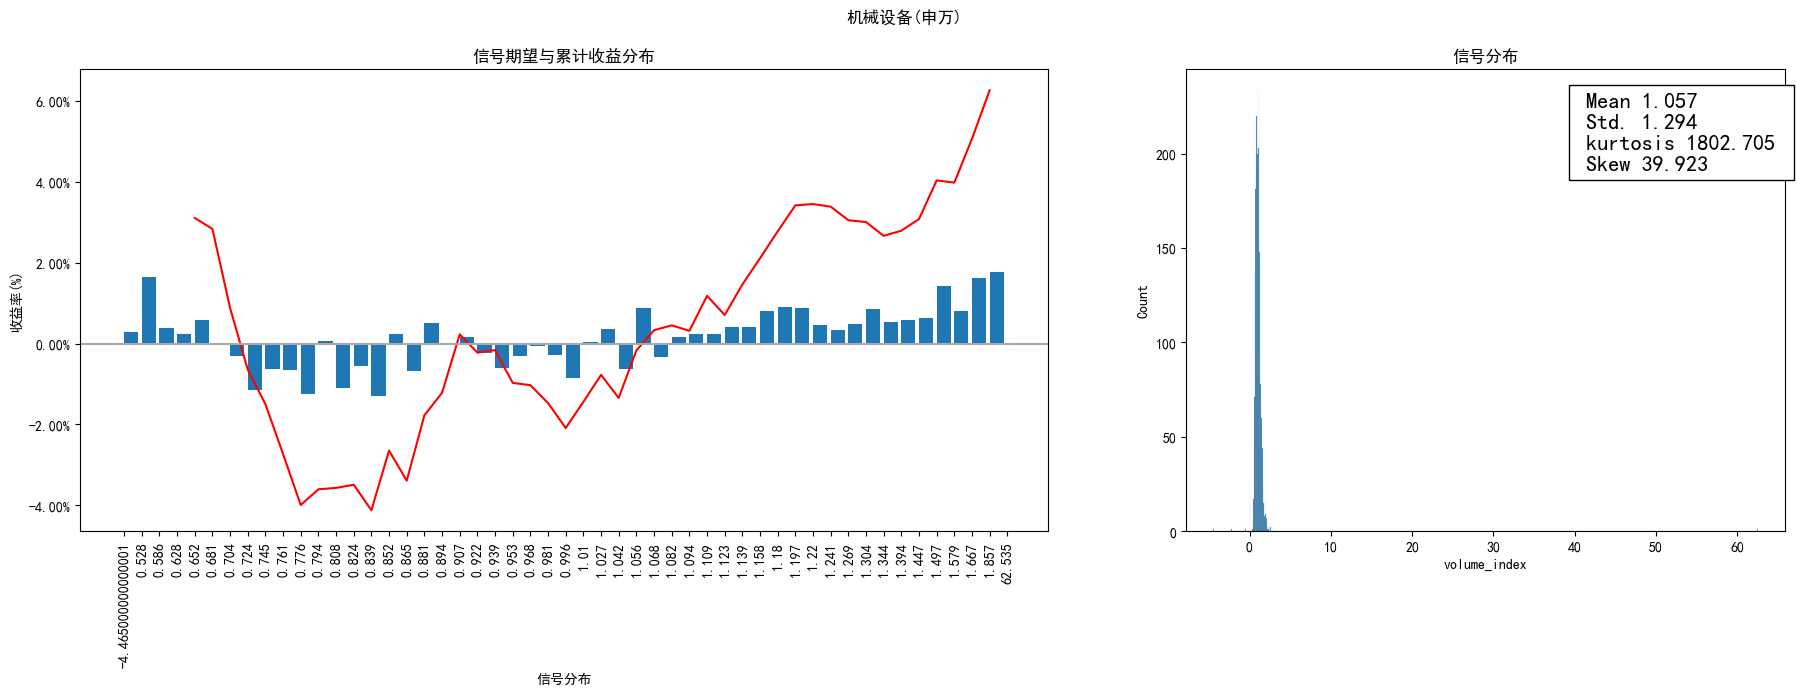

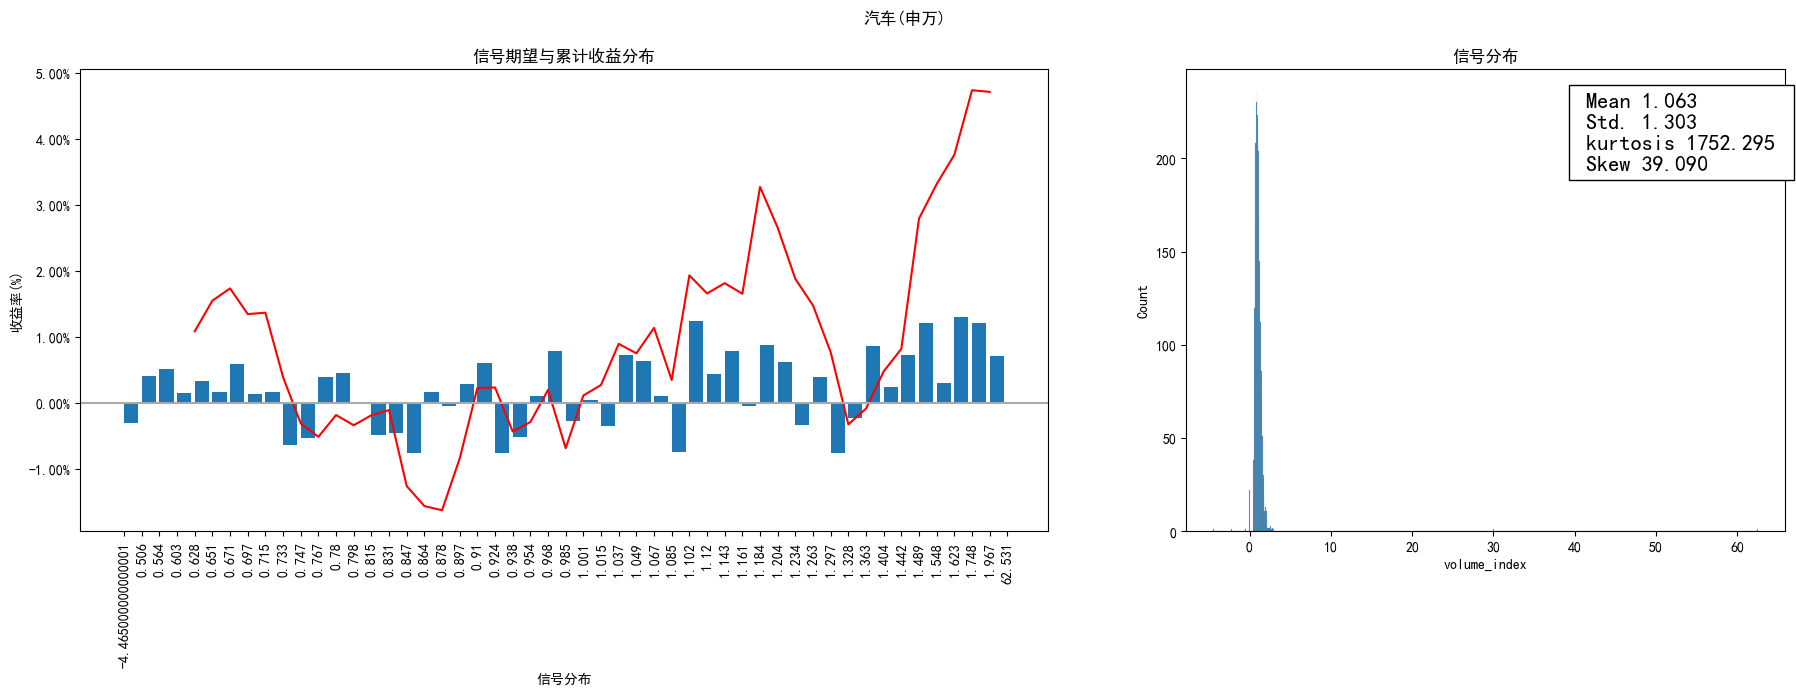

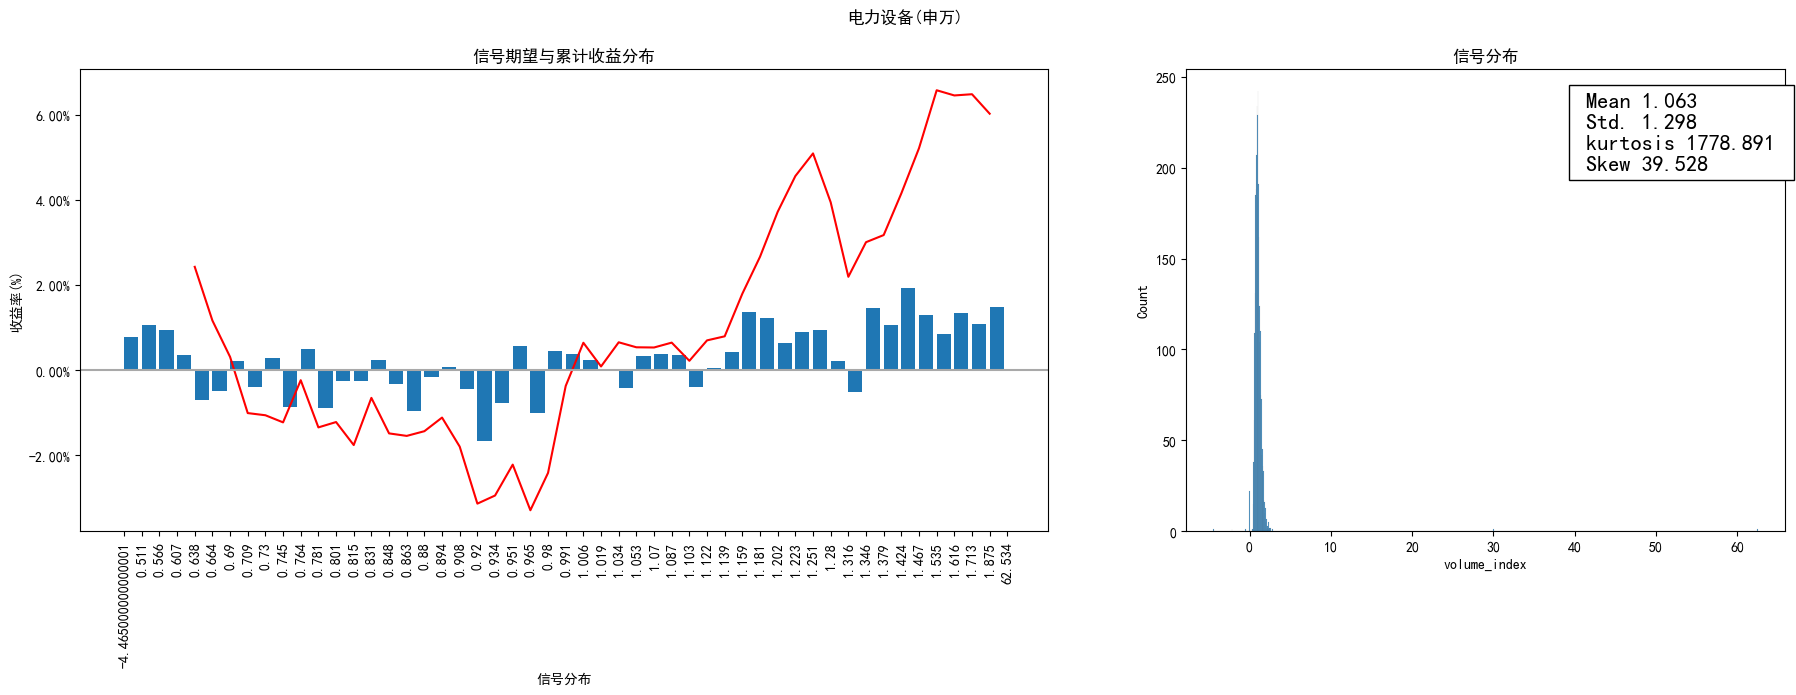

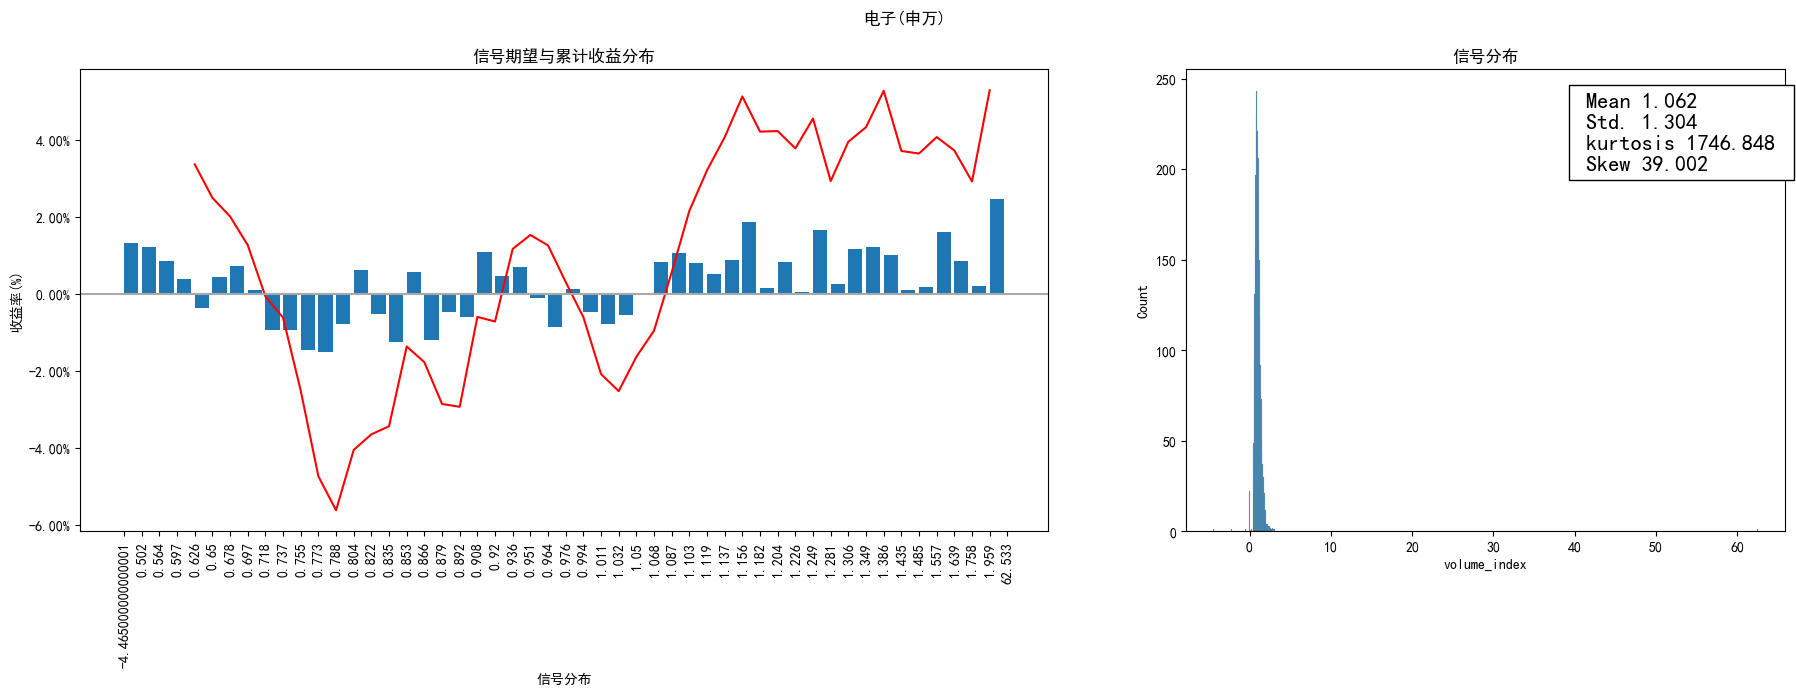

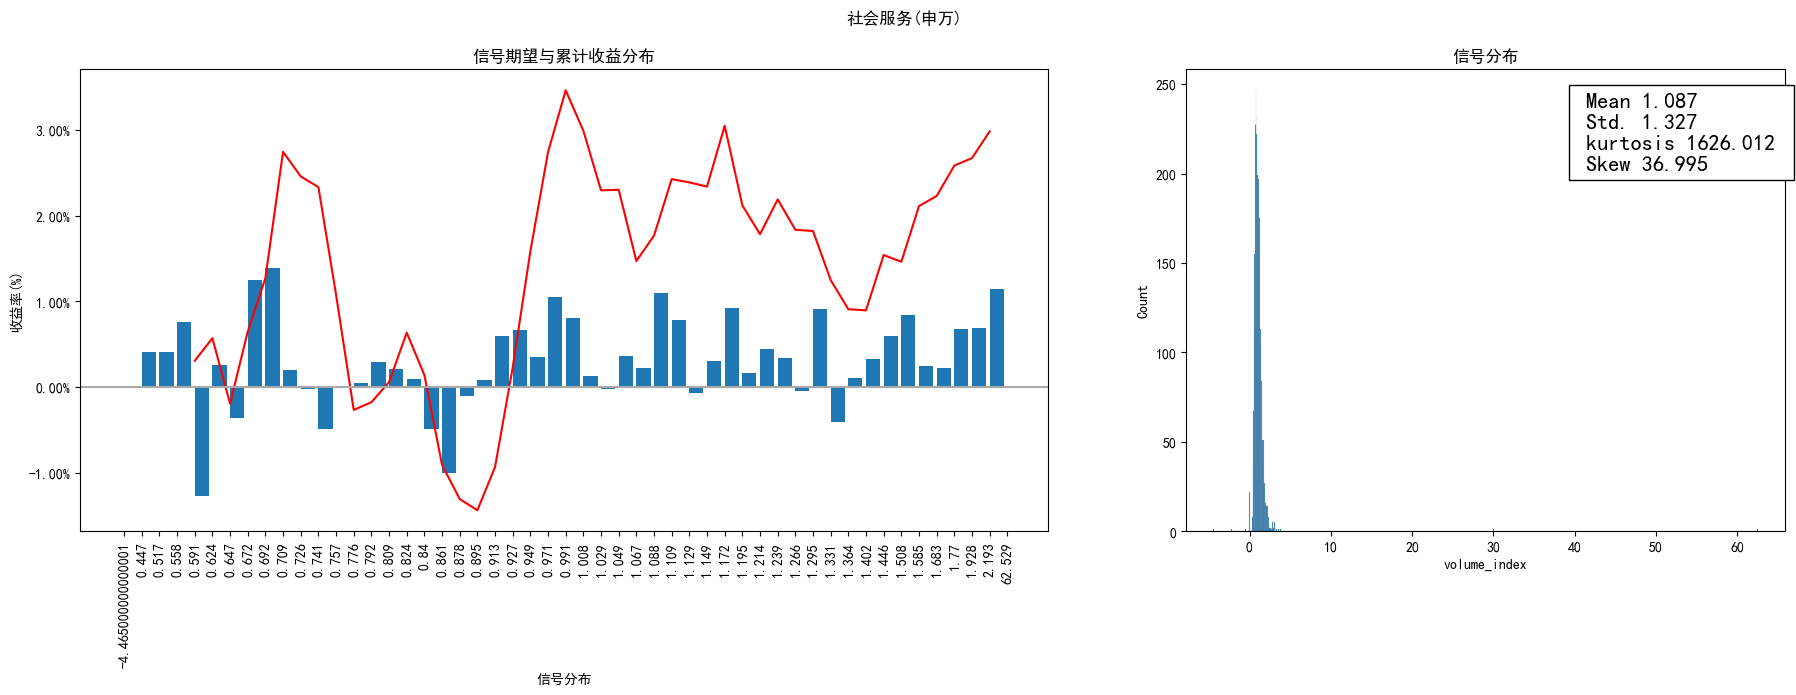

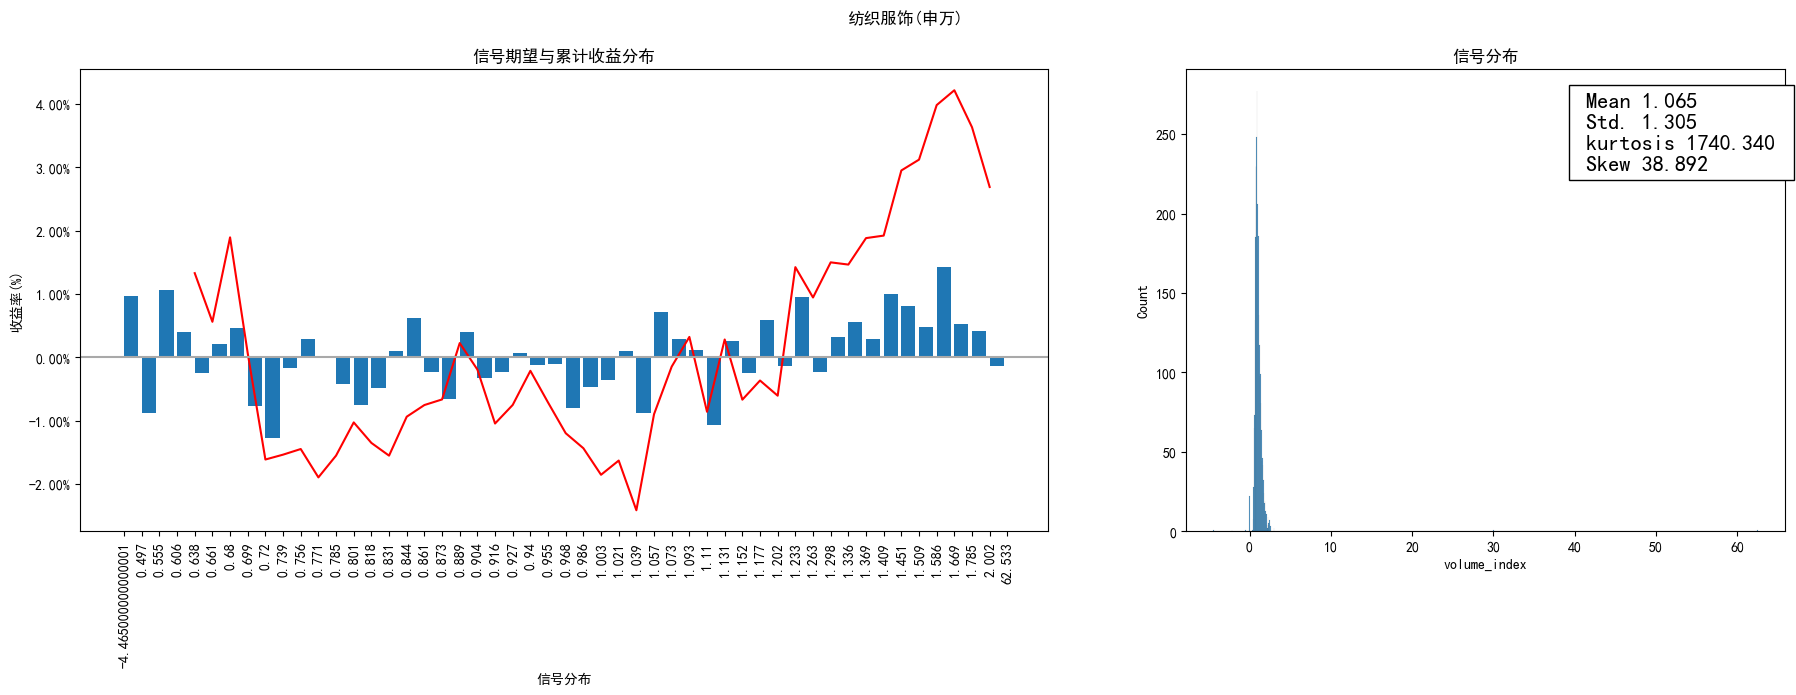

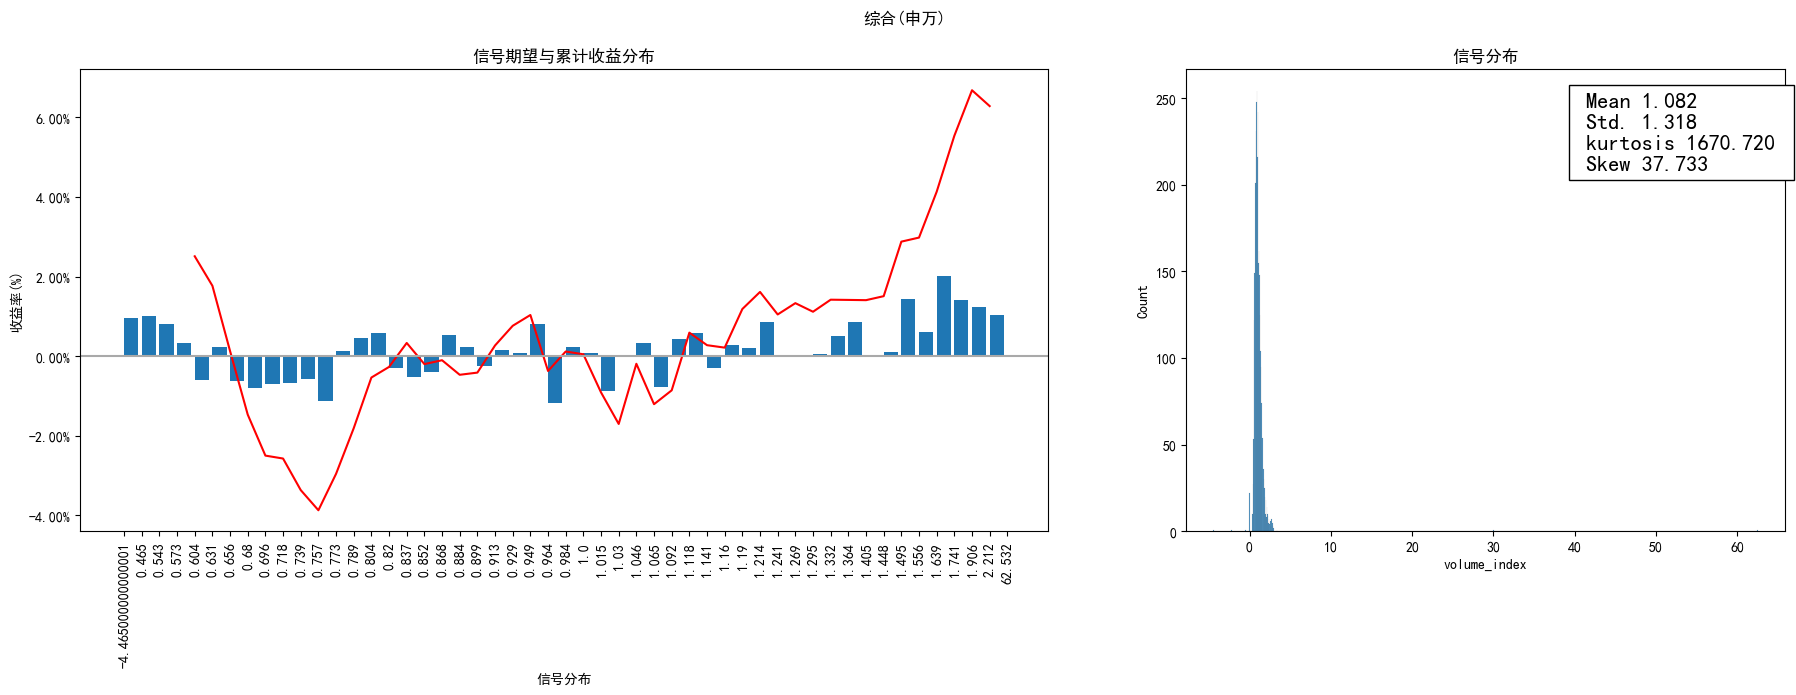

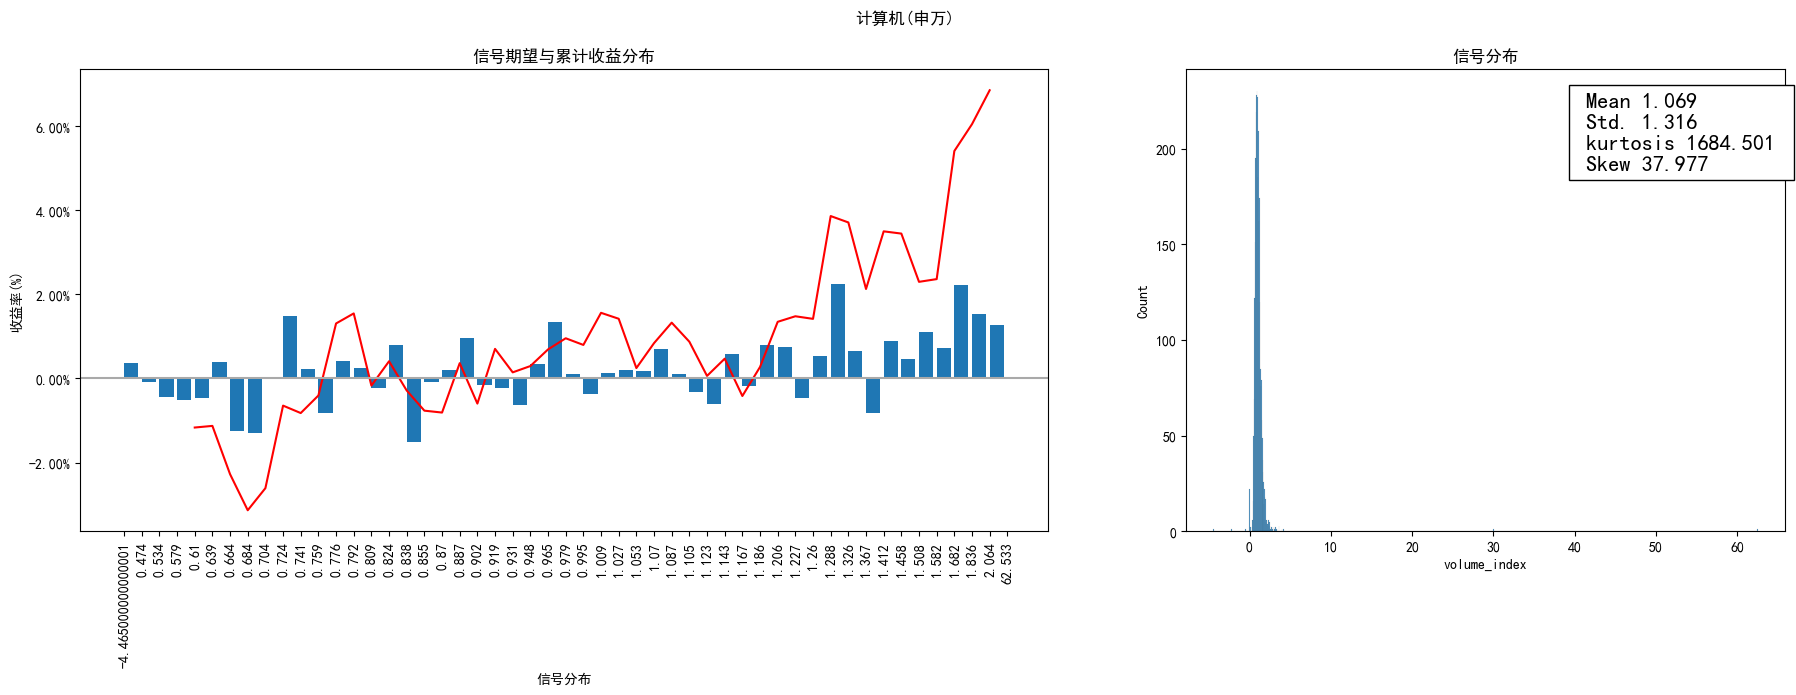

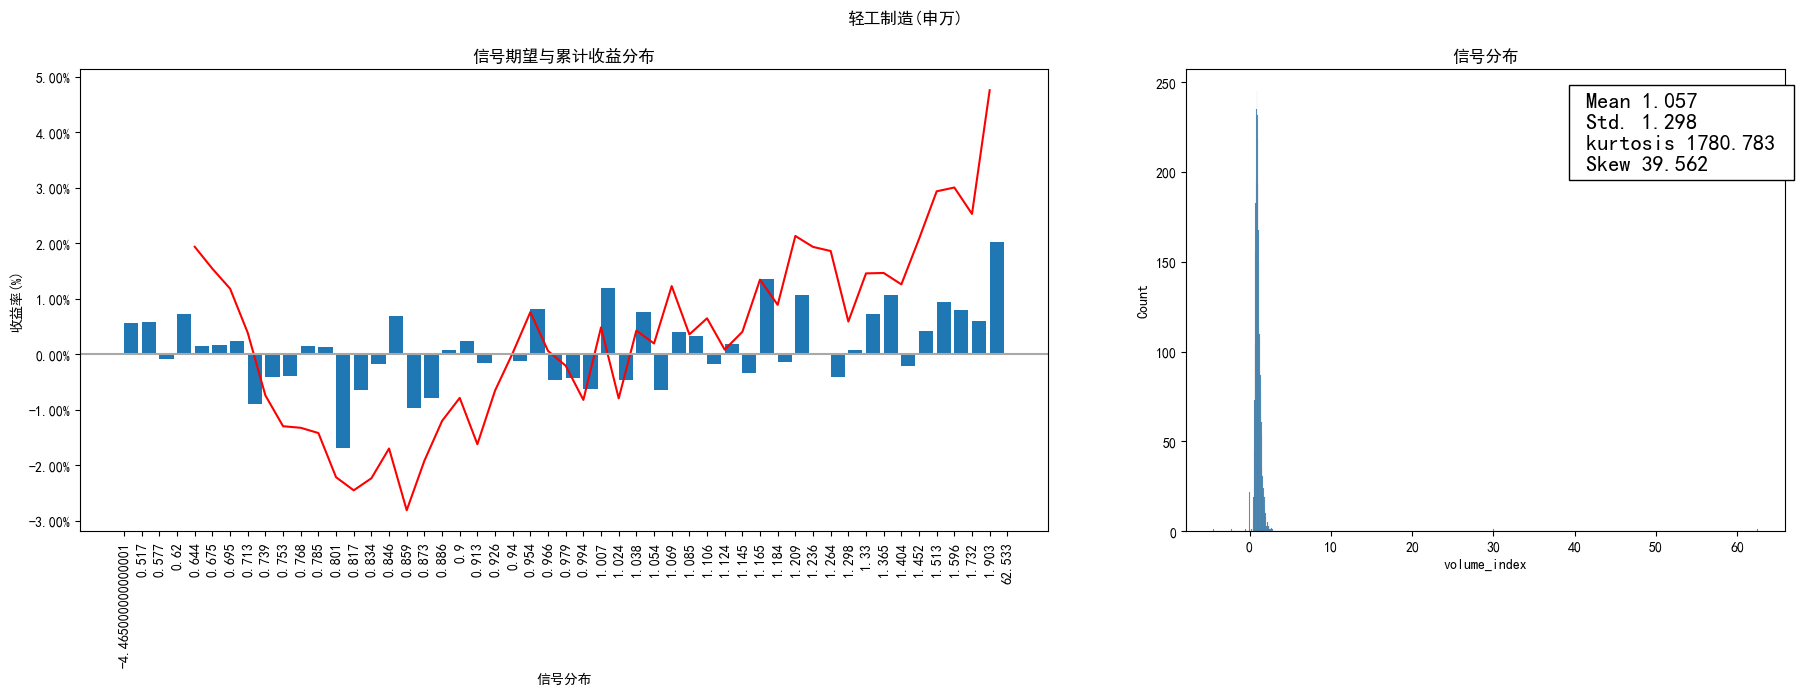

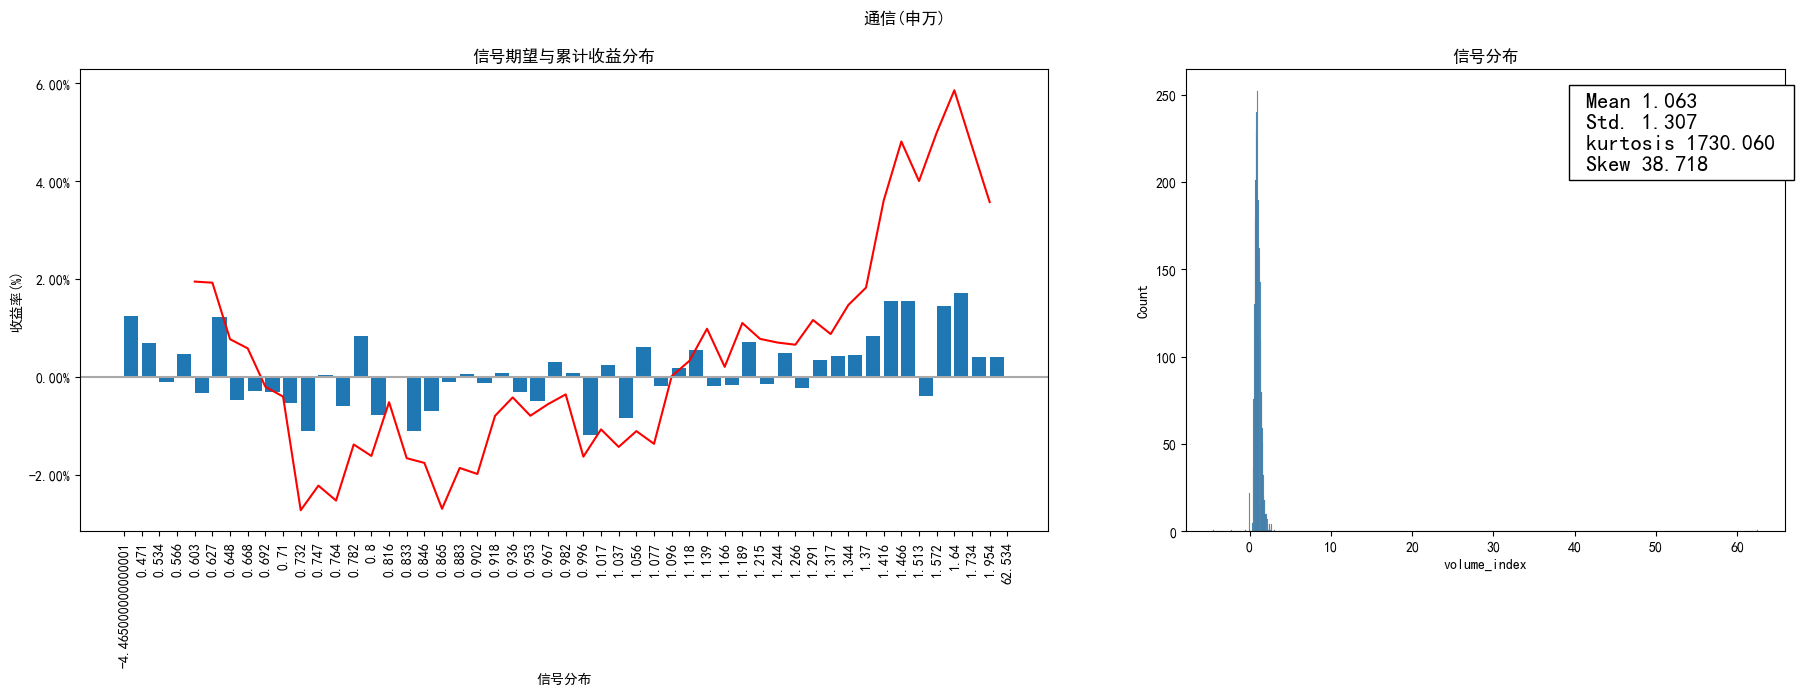

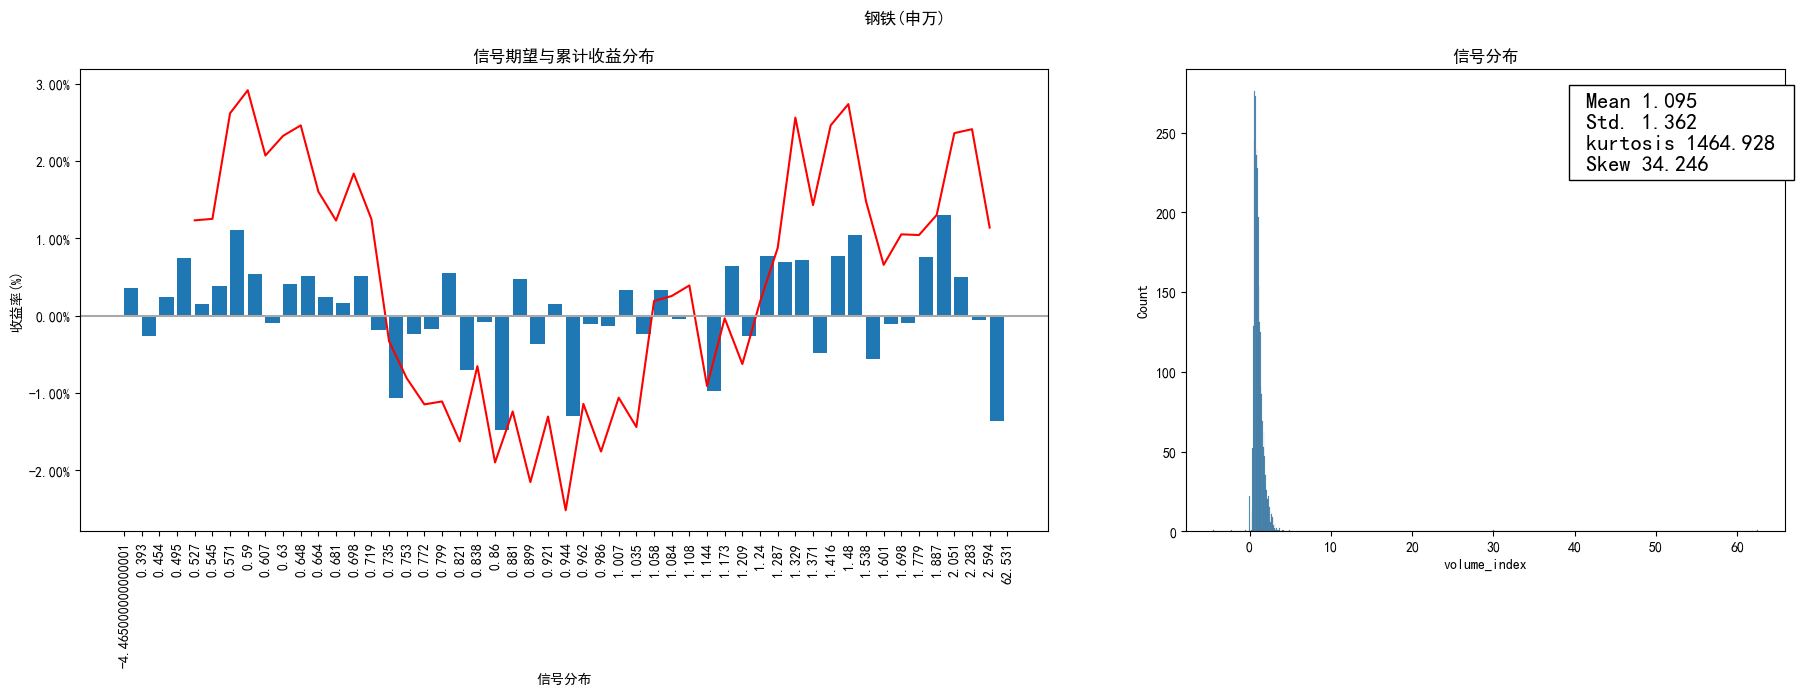

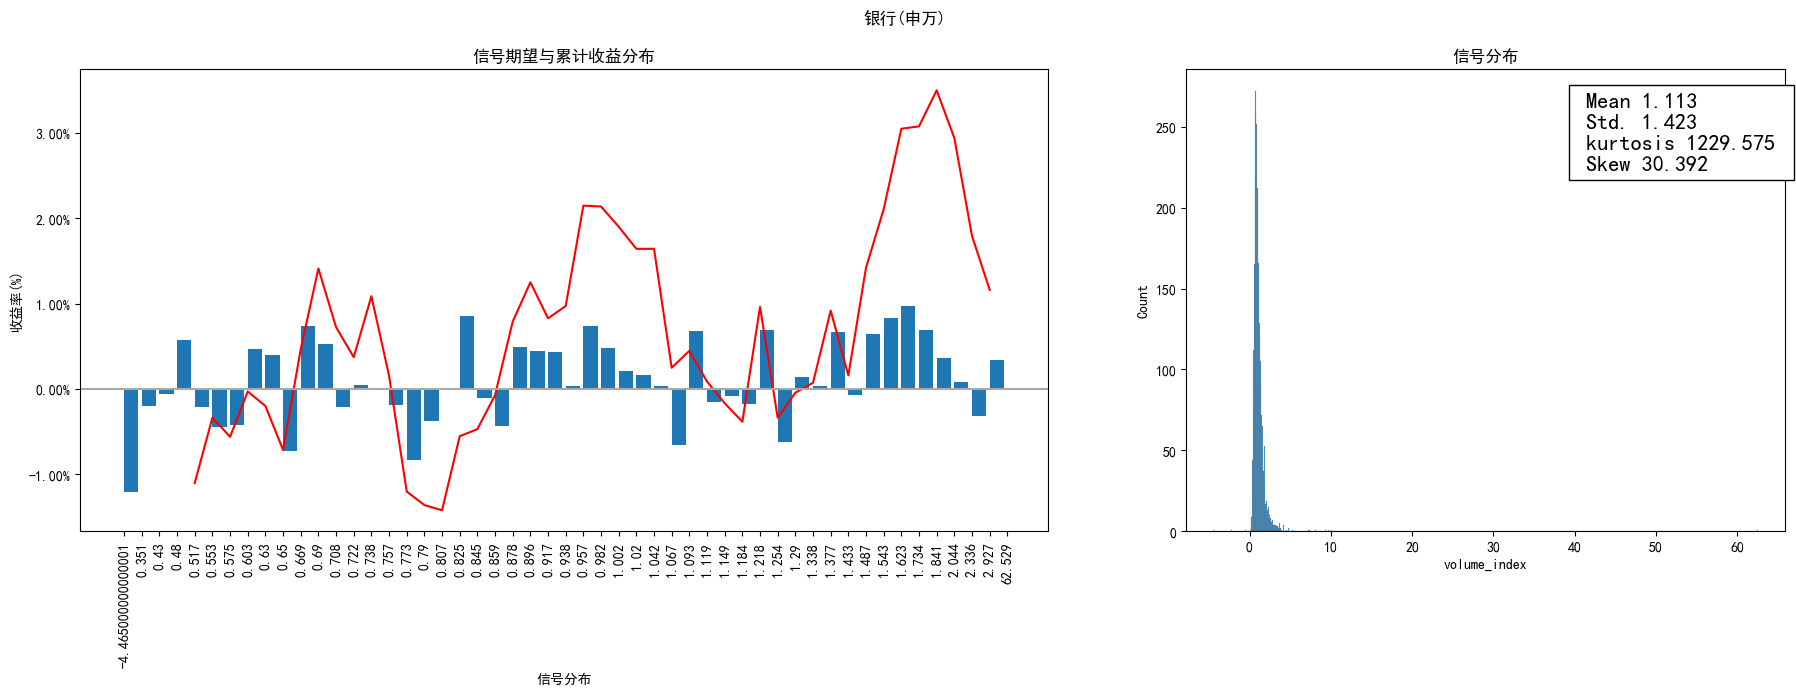

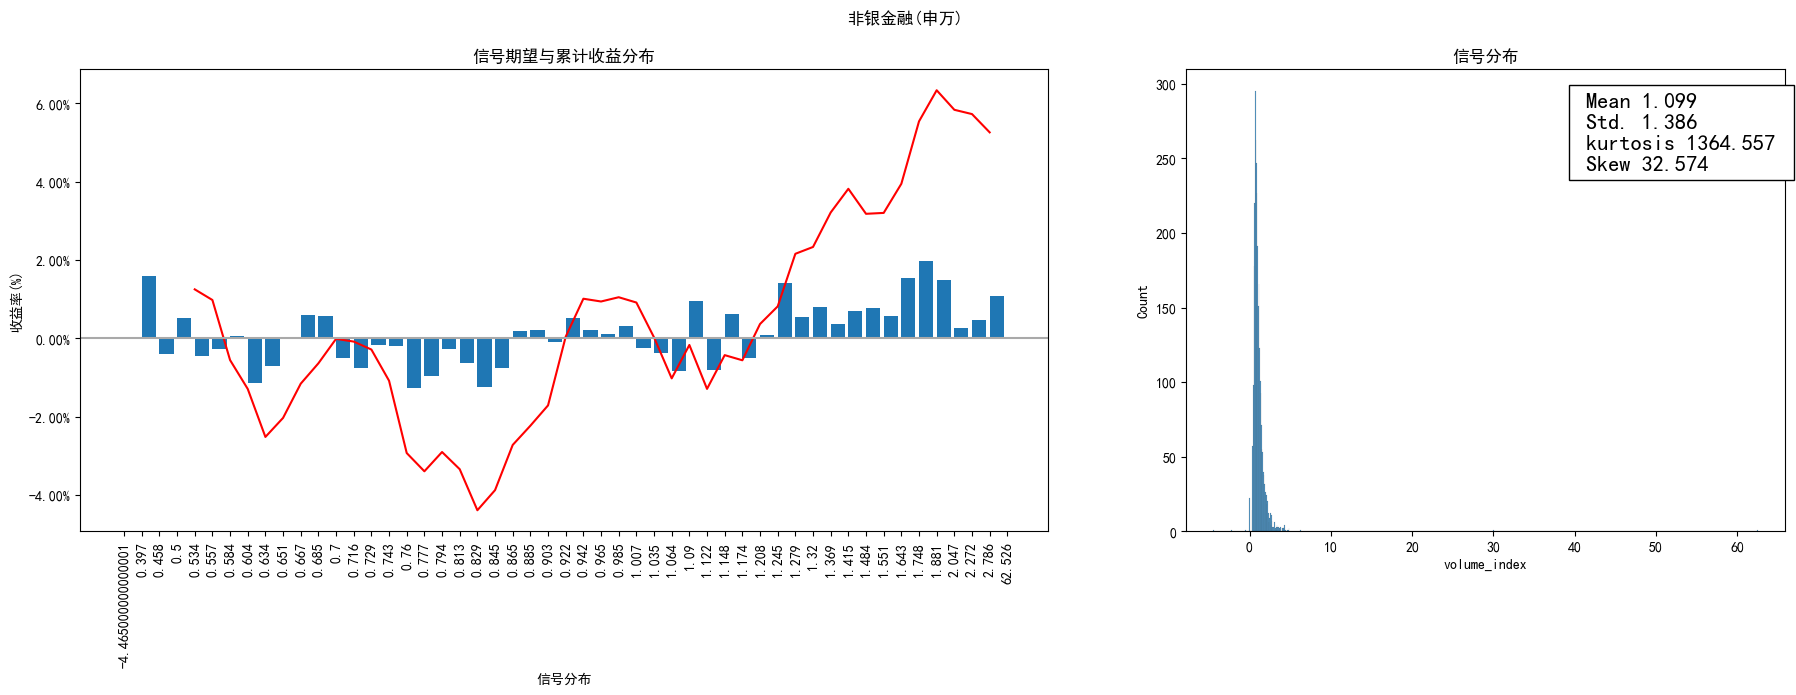

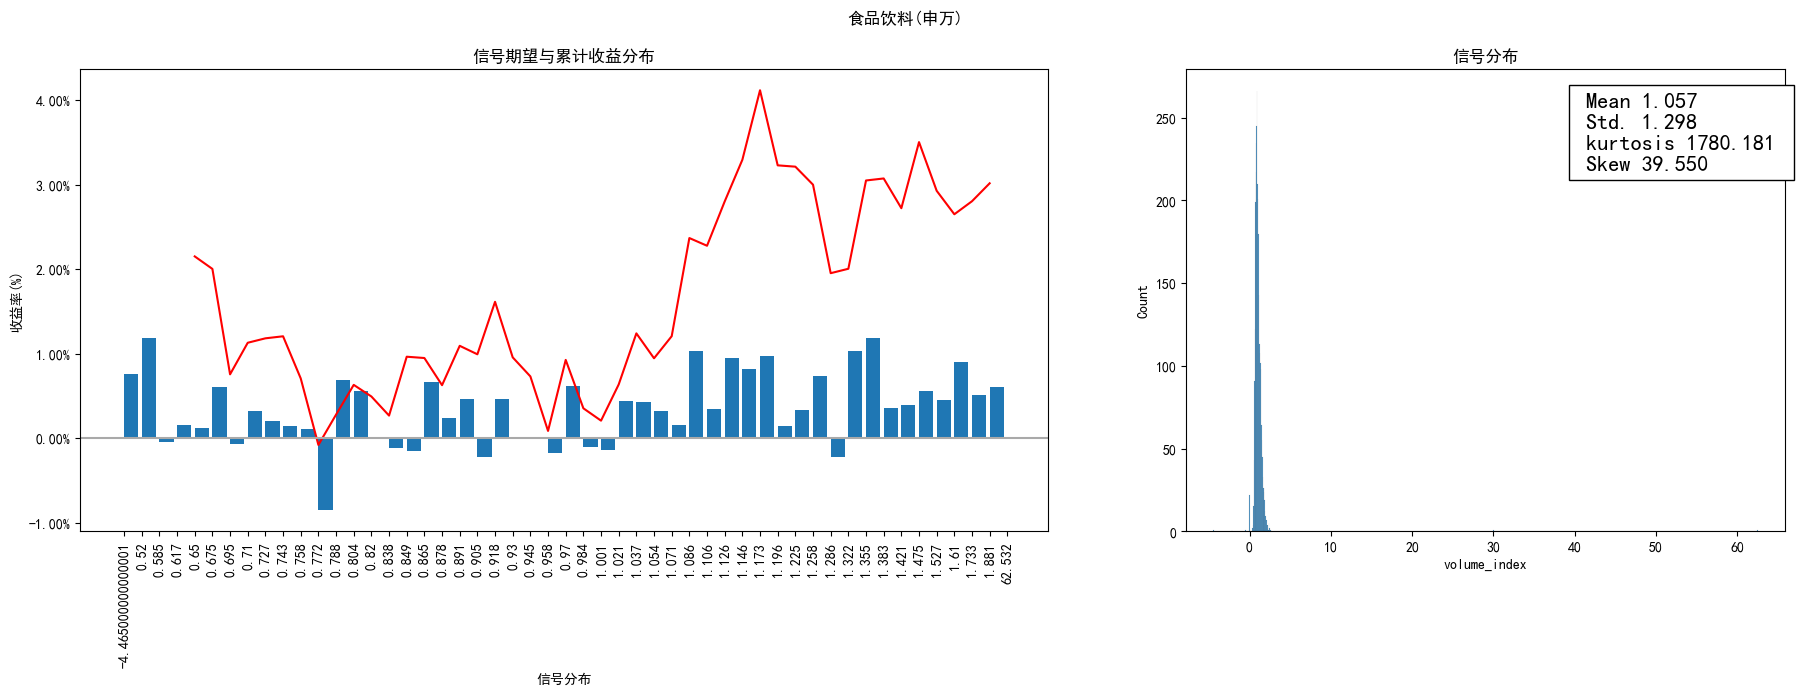

In [47]:
for name, df in sw_level.groupby("code"):

    df = create_signal(
        sw_level.query(f'code=="{name}"'),
        fast_window=5,
        slow_window=100,
        threshold=1.15,
        a=1.5,
    )

    plot_distribution(
        df["volume_index"], df["forward_returns"], 5, 50, False, title=name
    )

信号分布不适合的行业,回测结果也是不好的

In [48]:
bt_inde_result: Dict = bulk_backtrader(sw_level, params=bulk_params1)

<Figure size 1400x9800 with 0 Axes>

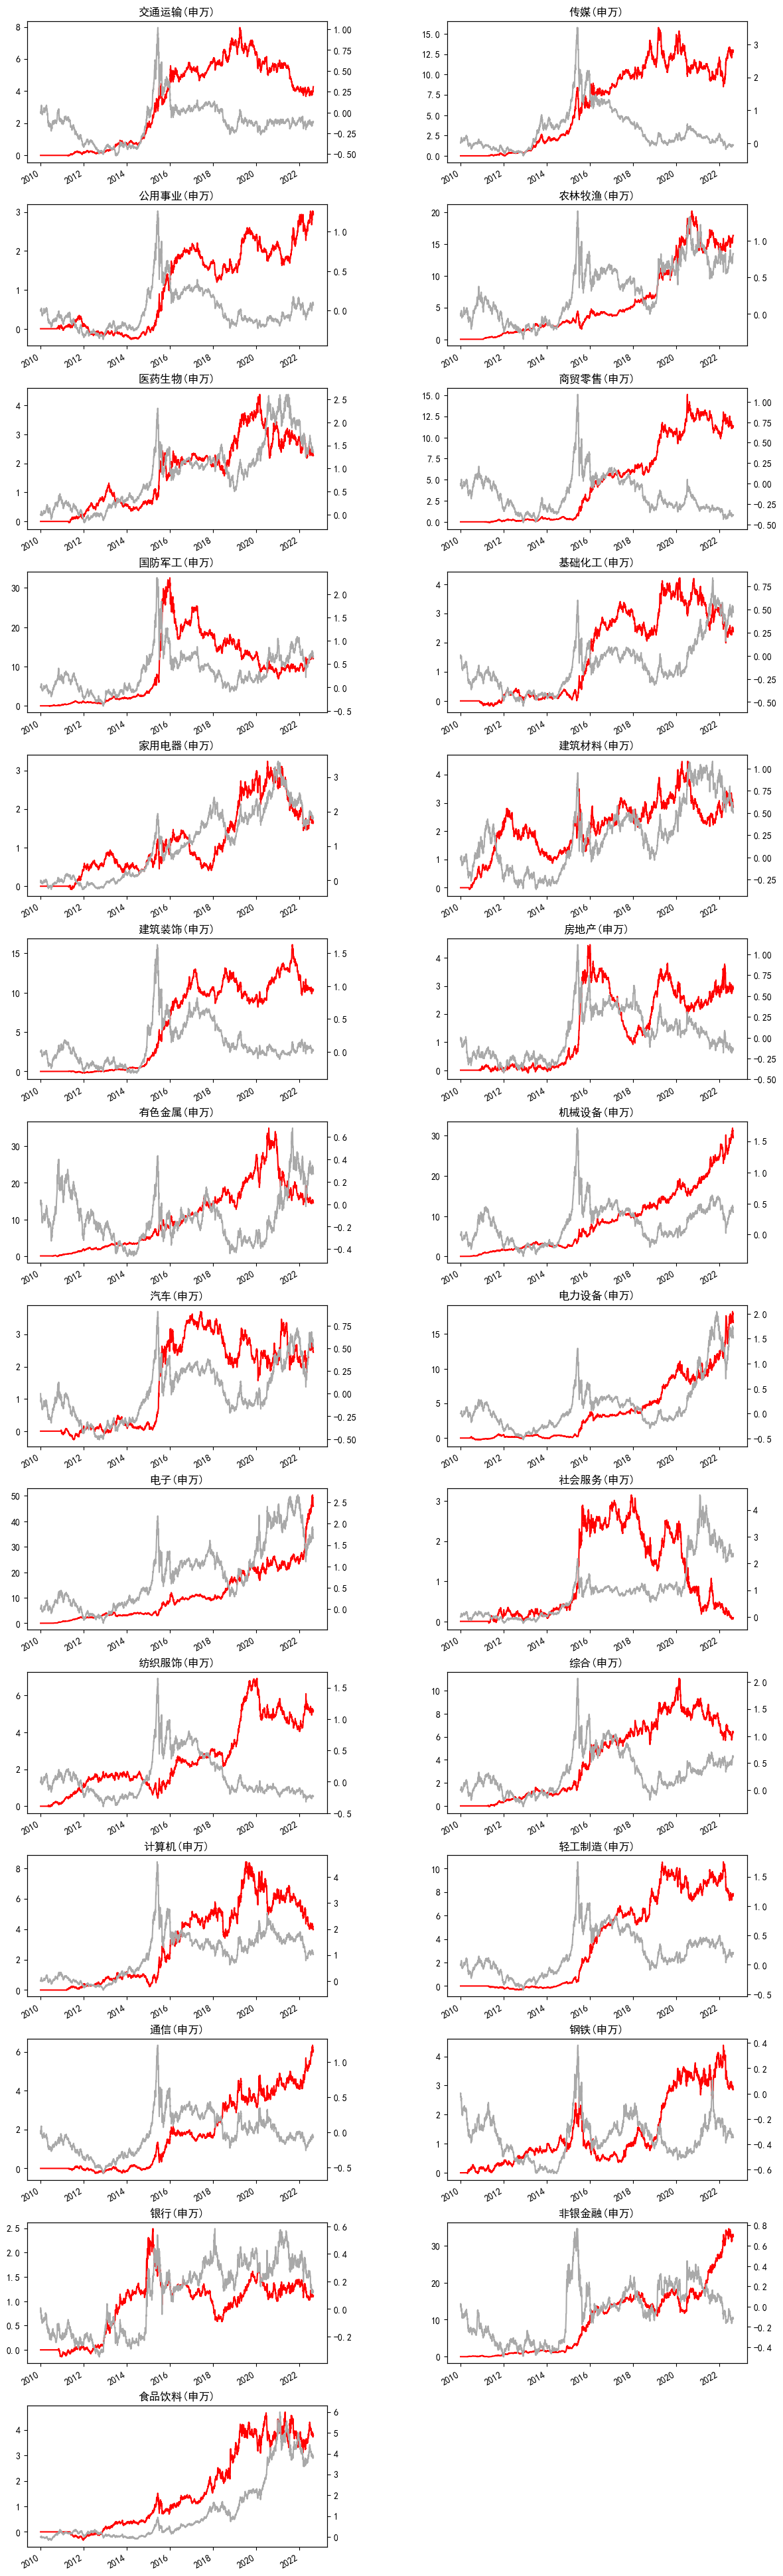

In [49]:
size = len(bt_inde_result)
cols = 2
rows = size // 2 + 1 if size % 2 else size * 0.5
g = GridFigure(rows, cols)
g.fig = plt.figure(figsize=(14, rows * 4))

for k, result in bt_inde_result.items():

    benchmark: pd.Series = sw_level.query(f'code=="{k}"')["close"]
    benchmark_ret: pd.Series = benchmark.pct_change()

    cum = ep.cum_returns(get_time_returns(result[0]))
    line_ax = cum.plot(title=k, color="r", ax=g.next_cell(), label=k)
    ep.cum_returns(benchmark_ret).plot(
        label="benchmark", ax=line_ax, color="darkgray", secondary_y=True
    )
    line_ax.set_xlabel("")
    plt.subplots_adjust(hspace=0.8)

plt.show()
g.close()